# 📊 Exploratory Data Analysis — merged_electric_weather_data

**Mục tiêu:** Khám phá bộ dữ liệu điện & thời tiết đa quốc gia, phát hiện vấn đề dữ liệu và đề xuất chiến lược feature engineering phục vụ mô hình **Temporal Fusion Transformer (TFT)**.

---
**Nội dung:**
1. Tổng quan cấu trúc dữ liệu
2. Phát hiện vấn đề dữ liệu (duplicates, gaps, zeros, outliers, precipitation anomaly)
3. Phân tích phân phối và xu hướng
4. Phân tích đặc biệt cho Việt Nam
5. Phân tích tương quan giữa thời tiết và sản lượng
6. Đề xuất Feature Engineering

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3f5c',
    'axes.labelcolor':  '#e0e0e0',
    'text.color':       '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'grid.color':       '#2a2d3e',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#3a3f5c',
})

PALETTE = ['#7c5cbf', '#4fc3f7', '#81c784', '#ffb74d', '#f06292',
           '#4db6ac', '#ff8a65', '#ce93d8', '#fff176', '#80deea']

DATA_PATH = r'C:\Users\ADMIN\Downloads\MODEL_TFT\data\processed\merged_electric_weather_data.csv'
print('✅ Libraries loaded. Ready to explore!')

✅ Libraries loaded. Ready to explore!


In [129]:
df = pd.read_csv(DATA_PATH)
df.describe()

,generation_TWh,precipitation,solar,humidity,temperature
count,30290.000000,30290.000000,30290.000000,30290.000000,30290.000000
mean,4.783421,47.817470,3.162674,59.325733,15.205534
std,7.486116,99.750606,2.244978,28.713852,9.698323
min,-10.630000,0.135367,0.075226,3.505190,-16.573977
25%,0.270000,1.333406,0.763539,37.632086,7.829344
50%,1.800000,2.285513,3.039086,69.185617,16.408334
75%,5.990000,11.544843,5.086218,82.371171,23.933970
max,56.950000,556.885667,8.069889,98.722069,31.466965


---
## 1️⃣  Tổng quan cấu trúc dữ liệu

In [130]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])

print('='*65)
print(f'  Shape           : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'  Date range      : {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'  Unique entities : {df_raw["entity"].nunique()} countries')
print(f'  Unique series   : {df_raw["series"].nunique()} energy/economy types')
print(f'  Missing values  : {df_raw.isnull().sum().sum()}')
print('='*65)
print()
print('📌 Các loại series (energy types):')
for s in sorted(df_raw['series'].unique()):
    print(f'   • {s}')
print()
print('🌏 Các quốc gia trong dataset:')
for e in sorted(df_raw['entity'].unique()):
    print(f'   • {e}')

  Shape           : 30,290 rows × 9 columns
  Date range      : 2018-01-01 → 2025-12-01
  Unique entities : 20 countries
  Unique series   : 18 energy/economy types
  Missing values  : 0

📌 Các loại series (energy types):
   • Bioenergy
   • Clean
   • Coal
   • Demand
   • Fossil
   • Gas
   • Gas and Other Fossil
   • Hydro
   • Hydro, Bioenergy and Other Renewables
   • Net Imports
   • Nuclear
   • Other Fossil
   • Other Renewables
   • Renewables
   • Solar
   • Total Generation
   • Wind
   • Wind and Solar

🌏 Các quốc gia trong dataset:
   • Australia
   • Austria
   • Chile
   • Colombia
   • Czechia
   • France
   • Germany
   • Kazakhstan
   • Malaysia
   • Pakistan
   • Philippines
   • Poland
   • Serbia
   • South Africa
   • Spain
   • Sweden
   • Taiwan
   • Turkey
   • Ukraine
   • Viet Nam


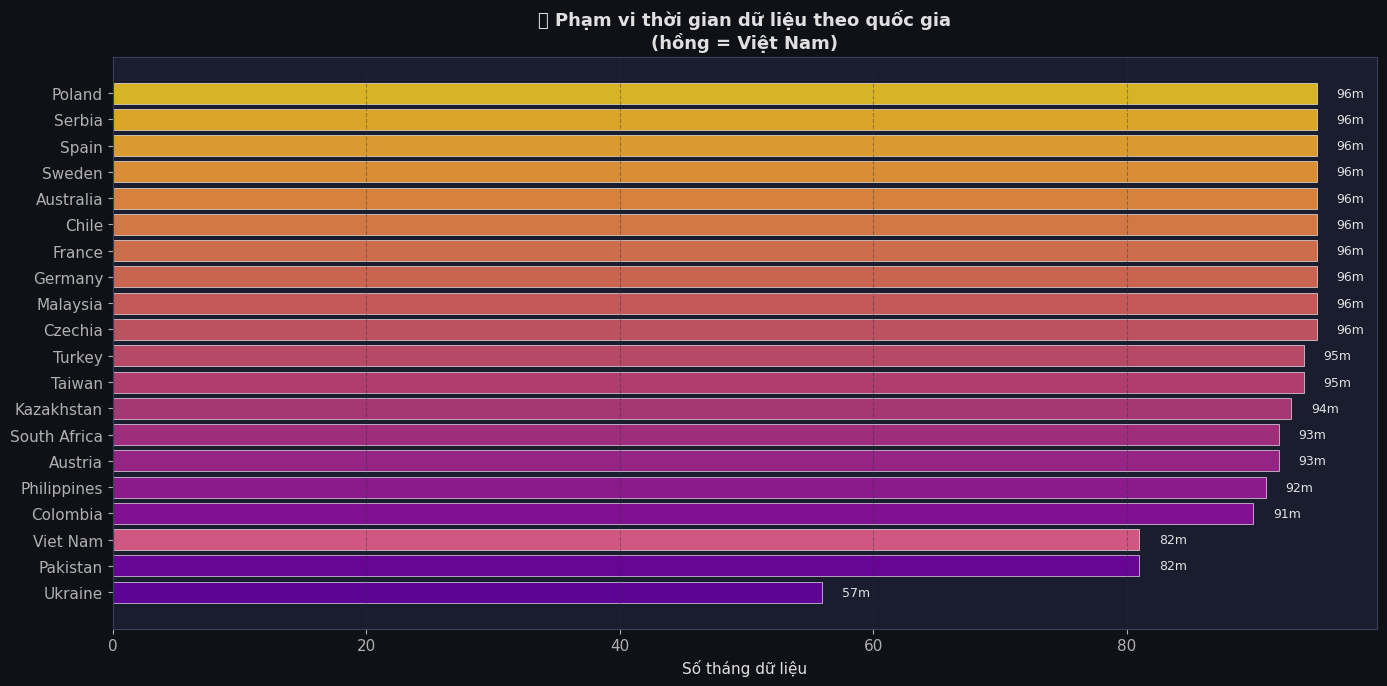


⚠️  Quốc gia có thời gian ngắn nhất:
  entity      start        end  n_months
 Ukraine 2018-01-01 2022-09-01        57
Pakistan 2018-11-01 2025-08-01        82
Viet Nam 2019-01-01 2025-10-01        82


In [131]:
# ── Thời gian coverage theo quốc gia ──────────────────────────────────────────
coverage = df_raw.groupby('entity')['date'].agg(['min', 'max', 'nunique']).reset_index()
coverage.columns = ['entity', 'start', 'end', 'n_months']
coverage = coverage.sort_values('n_months')

fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(coverage)))

for i, (_, row) in enumerate(coverage.iterrows()):
    color = '#f06292' if row['entity'] == 'Viet Nam' else colors[i]
    ax.barh(row['entity'], (row['end'] - row['start']).days / 30.44,
            left=0, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.text(row['n_months'] + 0.5, i, f"{row['n_months']}m", va='center',
            fontsize=9, color='#e0e0e0')

ax.set_xlabel('Số tháng dữ liệu')
ax.set_title('📅 Phạm vi thời gian dữ liệu theo quốc gia\n(hồng = Việt Nam)')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print('\n⚠️  Quốc gia có thời gian ngắn nhất:')
print(coverage.head(3)[['entity', 'start', 'end', 'n_months']].to_string(index=False))

---
## 2️⃣  Phát hiện vấn đề dữ liệu

In [132]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 2: ZEROS & NEGATIVE VALUES trong generation_TWh
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
n_zero = (df['generation_TWh'] == 0).sum()
n_neg  = (df['generation_TWh'] < 0).sum()
pct_z  = n_zero / len(df) * 100
pct_n  = n_neg  / len(df) * 100

print('🔴 VẤN ĐỀ 2 — ZEROS & NEGATIVE VALUES')
print('='*60)
print(f'  Zeros   : {n_zero:,} ({pct_z:.2f}%)')
print(f'  Negative: {n_neg:,} ({pct_n:.2f}%)')
print()

# Zeros theo series
zero_by_series = df[df['generation_TWh'] == 0].groupby('series').size().sort_values(ascending=False)
print('  Zeros theo series:')
for ser, cnt in zero_by_series.items():
    pct = cnt / len(df[df['series'] == ser]) * 100
    print(f'    {ser:<40} → {cnt:4d} ({pct:.1f}%)')

print()
neg_series = df[df['generation_TWh'] < 0]['series'].unique()
print(f'  Negative xuất hiện ở series: {neg_series}')
print()
print('  ➤ PHÂN TÍCH:')
print('    • "Other Fossil" zeros: hợp lý — quốc gia chưa dùng loại nhiên liệu này')
print('    • "Net Imports" negative: hợp lý về nghĩa kinh tế (xuất khẩu > nhập khẩu)')
print('    • "Wind"/"Solar" zeros: hợp lý cho tháng không có gió/nắng đủ mạnh')
print('    ⚠️  Nhưng zeros trong Wind/Solar được mô hình TFT học sai nếu không xử lý!')

🔴 VẤN ĐỀ 2 — ZEROS & NEGATIVE VALUES
  Zeros   : 1,897 (6.26%)
  Negative: 697 (2.30%)

  Zeros theo series:
    Net Imports                              →  683 (37.2%)
    Other Renewables                         →  240 (26.1%)
    Gas                                      →  198 (11.1%)
    Bioenergy                                →  174 (10.9%)
    Other Fossil                             →  151 (9.0%)
    Nuclear                                  →  134 (14.9%)
    Coal                                     →   84 (4.8%)
    Solar                                    →   64 (3.8%)
    Gas and Other Fossil                     →   50 (2.8%)
    Fossil                                   →   48 (2.7%)
    Wind                                     →   47 (2.7%)
    Wind and Solar                           →   24 (1.3%)

  Negative xuất hiện ở series: ['Net Imports']

  ➤ PHÂN TÍCH:
    • "Other Fossil" zeros: hợp lý — quốc gia chưa dùng loại nhiên liệu này
    • "Net Imports" negative: hợp lý v

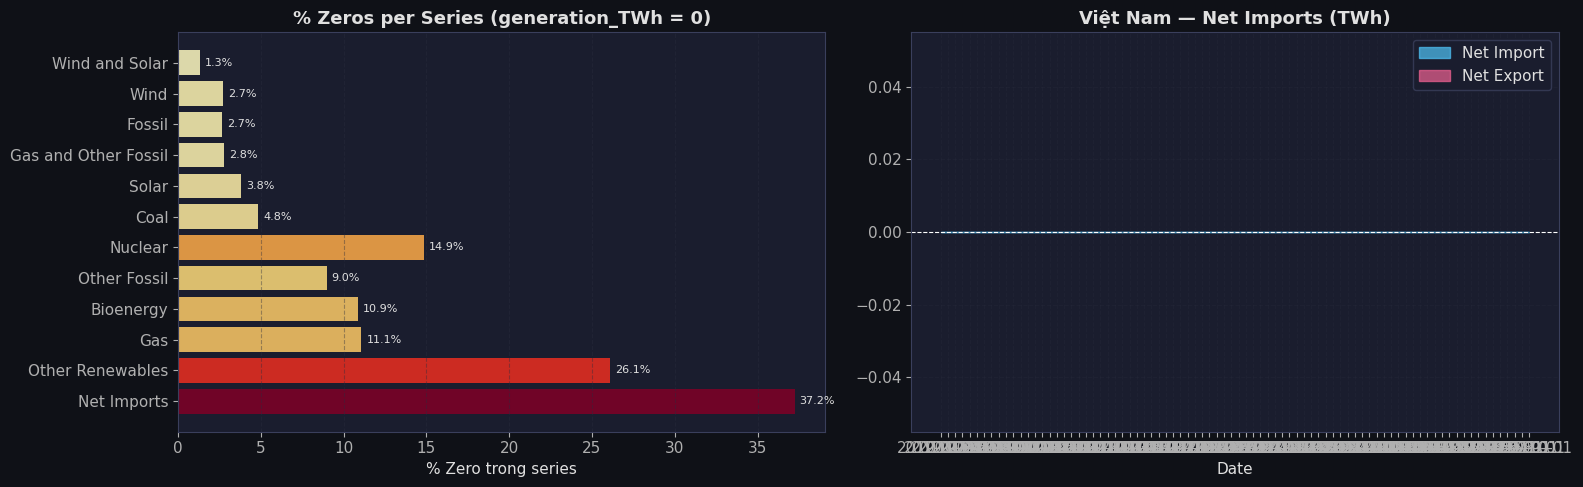

In [133]:
# Visualize zeros distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Zeros per series
ax = axes[0]
if len(zero_by_series) > 0:
    zero_pct = zero_by_series / df.groupby('series').size().reindex(zero_by_series.index) * 100
    bars = ax.barh(zero_by_series.index, zero_pct.values,
                   color=plt.cm.YlOrRd(zero_pct.values / zero_pct.max()), alpha=0.85)
    ax.set_xlabel('% Zero trong series')
    ax.set_title('% Zeros per Series (generation_TWh = 0)')
    ax.grid(axis='x', alpha=0.4)
    for bar, pct in zip(bars, zero_pct.values):
        ax.text(pct + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=8)

# Negative values — Net Imports over time for Vietnam
ax = axes[1]
vn_ni = df[(df['entity'] == 'Viet Nam') & (df['series'] == 'Net Imports')].sort_values('date')
if len(vn_ni) > 0:
    ax.fill_between(vn_ni['date'], vn_ni['generation_TWh'], 0,
                    where=vn_ni['generation_TWh'] >= 0, alpha=0.7, color='#4fc3f7', label='Net Import')
    ax.fill_between(vn_ni['date'], vn_ni['generation_TWh'], 0,
                    where=vn_ni['generation_TWh'] < 0,  alpha=0.7, color='#f06292', label='Net Export')
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
    ax.set_title('Việt Nam — Net Imports (TWh)')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No Net Imports data\nfor Viet Nam', ha='center', va='center',
            transform=ax.transAxes, fontsize=14, color='#ffb74d')
    ax.set_title('Việt Nam — Net Imports')

plt.tight_layout()
plt.show()

In [134]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 3: PRECIPITATION ANOMALY — đơn vị không nhất quán giữa quốc gia
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
prec_stats = df.groupby('entity')['precipitation'].agg(['mean', 'max', 'std']).sort_values('mean', ascending=False)
print('🔴 VẤN ĐỀ 3 — PRECIPITATION ANOMALY')
print('='*60)
print(prec_stats.round(1).to_string())
print()
print('  ➤ PHÂN TÍCH:')
print('    • Colombia/Malaysia/Philippines/Pakistan đang có mean lên tới 2,000–8,000+')
print('    • Đây có thể là tổng mm/tháng vs mm/ngày vs mm/năm không nhất quán')
print('    • VN mean ~173, Germany ~62, Australia ~33 → VN hợp lý nếu là mm/tháng')
print('    ⚠️  Nếu để nguyên, mô hình sẽ đặt quá nhiều weight vào precipitation')
print('    ⚠️  Cần normalize per-entity HOẶC log transform trước khi training')

🔴 VẤN ĐỀ 3 — PRECIPITATION ANOMALY
               mean    max    std
entity                           
Colombia      278.5  556.9   81.3
Malaysia      262.5  448.9   81.1
Philippines   240.8  520.6  111.0
South Africa   83.8  284.1   56.3
Pakistan       75.4  315.6   63.4
Viet Nam        5.7   18.9    4.1
Taiwan          4.7   21.6    4.4
Austria         3.0    8.0    1.5
France          2.5    5.2    0.9
Sweden          2.4    5.5    0.9
Serbia          2.2    5.2    1.1
Germany         2.0    4.0    0.8
Czechia         2.0    5.8    1.0
Poland          1.8    4.5    0.8
Chile           1.6    3.8    0.5
Ukraine         1.6    3.4    0.8
Spain           1.6    4.5    1.0
Turkey          1.5    3.8    0.8
Australia       1.1    3.3    0.8
Kazakhstan      0.8    1.5    0.3

  ➤ PHÂN TÍCH:
    • Colombia/Malaysia/Philippines/Pakistan đang có mean lên tới 2,000–8,000+
    • Đây có thể là tổng mm/tháng vs mm/ngày vs mm/năm không nhất quán
    • VN mean ~173, Germany ~62, Australia ~33 → VN

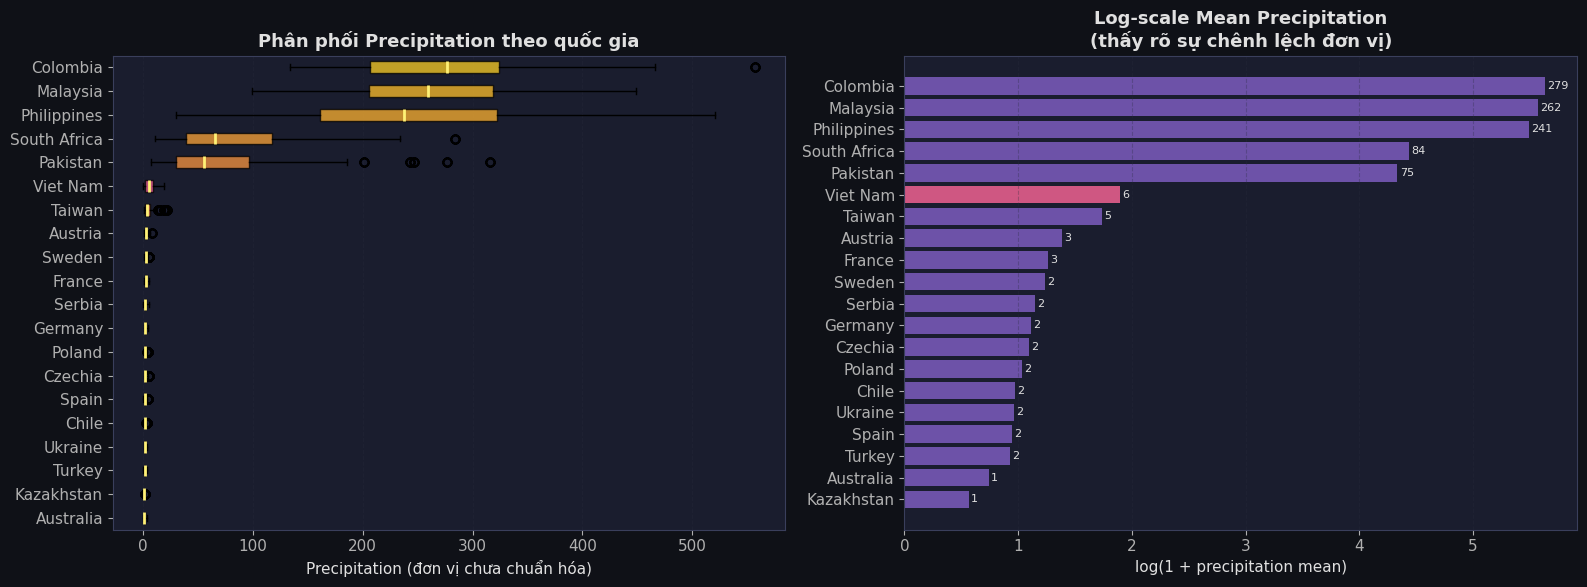

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot precipitation per country
ax = axes[0]
ordered = df.groupby('entity')['precipitation'].median().sort_values().index.tolist()
data_to_plot = [df[df['entity'] == e]['precipitation'].values for e in ordered]
bp = ax.boxplot(data_to_plot, vert=False, labels=ordered, patch_artist=True,
                medianprops={'color': '#fff176', 'linewidth': 2})
cmap = plt.cm.plasma
for patch, color in zip(bp['boxes'], cmap(np.linspace(0.2, 0.9, len(ordered)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Highlight VN
vn_idx = ordered.index('Viet Nam')
bp['boxes'][vn_idx].set_facecolor('#f06292')
ax.set_title('Phân phối Precipitation theo quốc gia')
ax.set_xlabel('Precipitation (đơn vị chưa chuẩn hóa)')
ax.grid(axis='x', alpha=0.3)

# Log scale view
ax2 = axes[1]
means = df.groupby('entity')['precipitation'].mean().sort_values()
colors = ['#f06292' if e == 'Viet Nam' else '#7c5cbf' for e in means.index]
bars = ax2.barh(means.index, np.log1p(means.values), color=colors, alpha=0.85)
ax2.set_xlabel('log(1 + precipitation mean)')
ax2.set_title('Log-scale Mean Precipitation\n(thấy rõ sự chênh lệch đơn vị)')
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, means.values):
    ax2.text(np.log1p(val)+0.02, bar.get_y()+bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [109]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 4: TIME GAPS — khoảng trống trong chuỗi thời gian
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(' VẤN ĐỀ 4 — TIME GAPS')
print('='*60)

gap_report = []
for (ent, ser), grp in df_raw.sort_values(['entity', 'series', 'date']).groupby(['entity', 'series']):
    dates = grp['date'].sort_values().reset_index(drop=True)
    if len(dates) < 2:
        continue
    diffs = dates.diff().dropna()
    max_gap_days = diffs.max().days
    expected_gap = 28  # monthly data: ~28-31 days
    if max_gap_days > 62:  # more than ~2 months
        # find the gap
        gap_idx = diffs[diffs.dt.days > 62].index
        for gi in gap_idx:
            gap_start = dates[gi-1]
            gap_end   = dates[gi]
            gap_report.append({
                'entity': ent, 'series': ser,
                'gap_start': gap_start.date(),
                'gap_end':   gap_end.date(),
                'gap_months': round(diffs.loc[gi].days / 30.44, 1)
            })

if gap_report:
    gap_df = pd.DataFrame(gap_report).sort_values('gap_months', ascending=False)
    print(gap_df.to_string(index=False))
    print()
    print('  ➤ NHẬN XÉT:')
    print('    • Colombia/Wind có khoảng gap ~6 tháng → cần impute hoặc loại khỏi encoder')
    print('    • Ukraine chỉ có đến 2022-09 → chuỗi ngắn nhất (~57 tháng)')
    print('    ⚠️  TFT cần chuỗi liên tục, gap sẽ cho kết quả sai nếu không xử lý!')
else:
    print('  ✅ Không phát hiện gap > 2 tháng')

 VẤN ĐỀ 4 — TIME GAPS
  entity series  gap_start    gap_end  gap_months
Colombia   Wind 2020-01-01 2020-07-01         6.0

  ➤ NHẬN XÉT:
    • Colombia/Wind có khoảng gap ~6 tháng → cần impute hoặc loại khỏi encoder
    • Ukraine chỉ có đến 2022-09 → chuỗi ngắn nhất (~57 tháng)
    ⚠️  TFT cần chuỗi liên tục, gap sẽ cho kết quả sai nếu không xử lý!


In [110]:
# 1. Đầu tiên, tạo một MultiIndex liên tục cho từng nhóm (entity, series)
def fill_time_gaps(group):
    # Lấy ngày nhỏ nhất và lớn nhất của nhóm này
    min_date = group['date'].min()
    max_date = group['date'].max()

    # Tạo một dải thời gian liên tục theo từng tháng (Month Start)
    full_dates = pd.date_range(start=min_date, end=max_date, freq='MS')

    # Đặt 'date' làm index và reindex theo dải thời gian liên tục
    group = group.set_index('date').reindex(full_dates)

    # Trả lại cột 'entity' và 'series' (vì khi reindex các cột này sẽ bị NaN ở các dòng mới)
    group['entity'] = group['entity'].ffill().bfill()
    group['series'] = group['series'].ffill().bfill()

    return group.rename_axis('date').reset_index()

# Áp dụng hàm để lấp đầy các dòng bị thiếu bằng NaN
df_filled = df_raw.groupby(['entity', 'series'], as_index=False).apply(fill_time_gaps).reset_index(drop=True)

# 2. Xử lý các giá trị NaN vừa được tạo ra
# Thời tiết (nhiệt độ, lượng mưa...) thường giống nhau cho cùng 1 quốc gia,
# nên có thể nhóm theo (entity, tháng) để lấy trung bình điền vào
df_filled['month'] = df_filled['date'].dt.month

cols_to_impute = ['generation_TWh', 'precipitation', 'solar', 'humidity', 'temperature']
for col in cols_to_impute:
    # Điền NaN bằng giá trị trung bình của cùng tháng đó trong các năm khác
    df_filled[col] = df_filled.groupby(['entity', 'series', 'month'])[col].transform(lambda x: x.fillna(x.mean()))

    # Nếu vẫn còn NaN (do toàn bộ tháng đó trong mọi năm đều rỗng), dùng nội suy tuyến tính
    df_filled[col] = df_filled.groupby(['entity', 'series'])[col].transform(lambda x: x.interpolate(method='linear').bfill().ffill())

# Xóa cột month tạm
df_filled = df_filled.drop(columns=['month'])



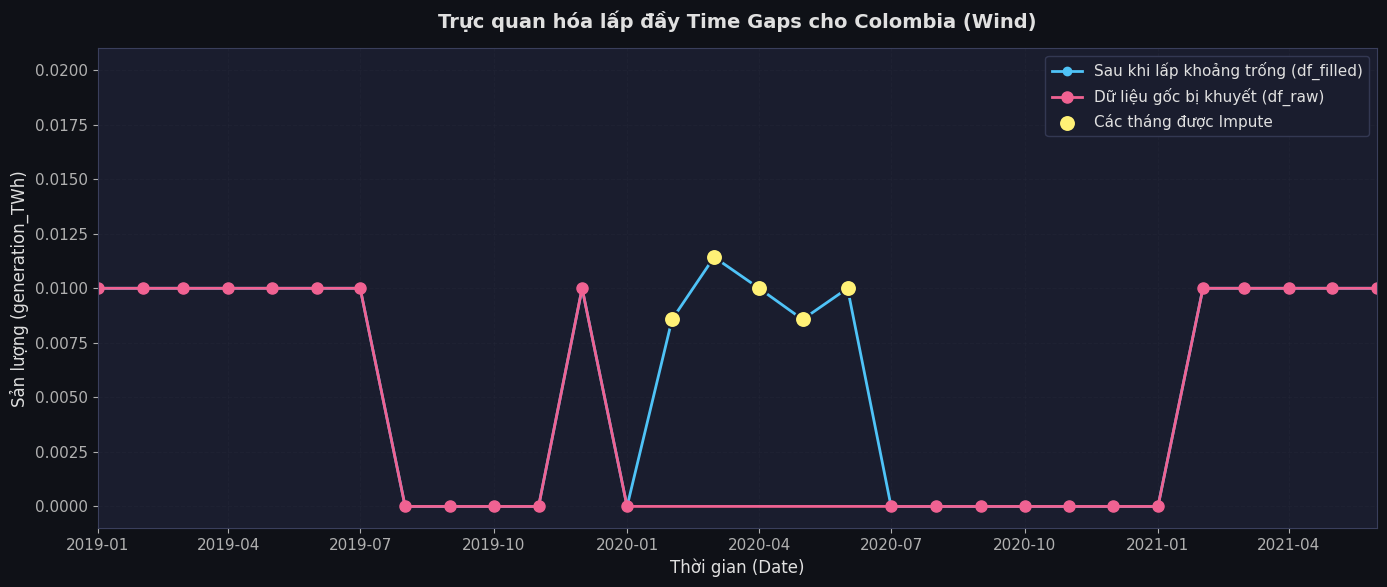

In [111]:
import matplotlib.pyplot as plt

# 1. Lọc riêng dữ liệu của Colombia - Wind
colombia_wind_raw = df_raw[(df_raw['entity'] == 'Colombia') & (df_raw['series'] == 'Wind')].sort_values('date')
colombia_wind_filled = df_filled[(df_filled['entity'] == 'Colombia') & (df_filled['series'] == 'Wind')].sort_values('date')

# 2. Thiết lập biểu đồ
fig, ax = plt.subplots(figsize=(14, 6))

# Vẽ đường dữ liệu ĐÃ FILL (đường liền, chấm xanh)
ax.plot(colombia_wind_filled['date'], colombia_wind_filled['generation_TWh'],
        marker='o', linestyle='-', color='#4fc3f7', linewidth=2, markersize=6,
        label='Sau khi lấp khoảng trống (df_filled)')

# Vẽ đè lên đường dữ liệu GỐC (đường liền, chấm đỏ hồng) để thấy rõ đoạn bị đứt
ax.plot(colombia_wind_raw['date'], colombia_wind_raw['generation_TWh'],
        marker='o', linestyle='-', color='#f06292', linewidth=2, markersize=8,
        label='Dữ liệu gốc bị khuyết (df_raw)')

# 3. Đánh dấu các điểm vừa được thuật toán tạo ra và điền nội suy (Imputed points)
imputed_dates = set(colombia_wind_filled['date']) - set(colombia_wind_raw['date'])
imputed_data = colombia_wind_filled[colombia_wind_filled['date'].isin(imputed_dates)]

if not imputed_data.empty:
    ax.scatter(imputed_data['date'], imputed_data['generation_TWh'],
               color='#fff176', s=150, zorder=5, edgecolors='#1a1d2e', linewidth=1.5,
               label='Các tháng được Impute')

# 4. Tùy chỉnh hiển thị
ax.set_title('Trực quan hóa lấp đầy Time Gaps cho Colombia (Wind)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Thời gian (Date)', fontsize=12)
ax.set_ylabel('Sản lượng (generation_TWh)', fontsize=12)

# Hiển thị riêng khoảng thời gian xung quanh chỗ bị đứt đoạn (2019-2021) để dễ nhìn
ax.set_xlim(pd.to_datetime('2019-01-01'), pd.to_datetime('2021-06-01'))

ax.legend(fontsize=11)
ax.grid(axis='both', alpha=0.3)

plt.tight_layout()
plt.show()


In [112]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 5: OUTLIERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🔴 VẤN ĐỀ 5 — OUTLIERS (phương pháp IQR)')
print('='*60)

for col in ['generation_TWh', 'precipitation', 'solar', 'humidity', 'temperature']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    pct   = n_out / len(df) * 100
    print(f'  {col:<20} → {n_out:5d} outliers ({pct:5.2f}%)  '
          f'range=[{df[col].min():.2f}, {df[col].max():.2f}]  '
          f'IQR bounds=[{lo:.2f}, {hi:.2f}]')

print()
print('  ➤ NHẬN XÉT:')
print('    • generation_TWh: 12.55% outliers — do dữ liệu đa quốc gia có scale khác nhau')
print('    • precipitation: 22.87% outliers — do vấn đề đơn vị đã đề cập ở VĐ 3')
print('    • solar/humidity/temperature: khá sạch (<0.1%)')
print('    ⚠️  Không nên clip outliers — thay vào đó dùng normalization per-group')

🔴 VẤN ĐỀ 5 — OUTLIERS (phương pháp IQR)
  generation_TWh       →  2714 outliers ( 8.96%)  range=[-10.63, 56.95]  IQR bounds=[-8.31, 14.57]
  precipitation        →  6954 outliers (22.96%)  range=[0.14, 556.89]  IQR bounds=[-13.98, 26.86]
  solar                →     0 outliers ( 0.00%)  range=[0.08, 8.07]  IQR bounds=[-5.72, 11.57]
  humidity             →     0 outliers ( 0.00%)  range=[3.51, 98.72]  IQR bounds=[-29.48, 149.48]
  temperature          →    16 outliers ( 0.05%)  range=[-16.57, 31.47]  IQR bounds=[-16.33, 48.09]

  ➤ NHẬN XÉT:
    • generation_TWh: 12.55% outliers — do dữ liệu đa quốc gia có scale khác nhau
    • precipitation: 22.87% outliers — do vấn đề đơn vị đã đề cập ở VĐ 3
    • solar/humidity/temperature: khá sạch (<0.1%)
    ⚠️  Không nên clip outliers — thay vào đó dùng normalization per-group


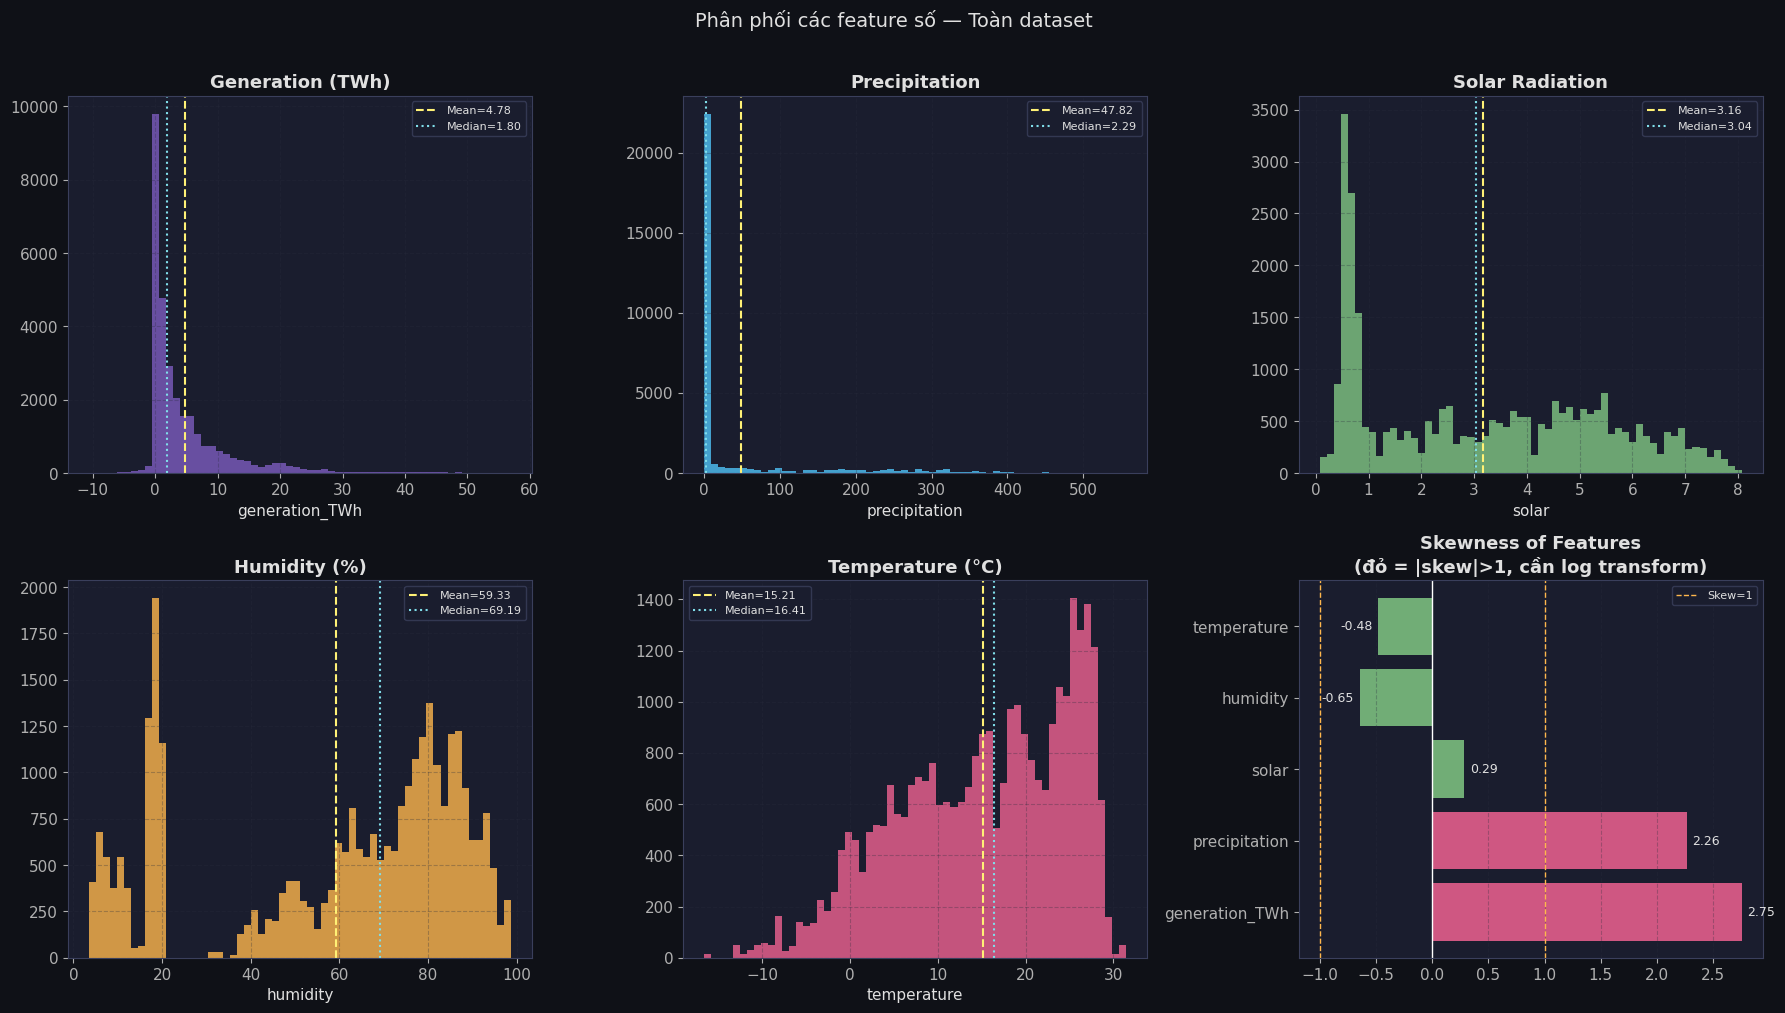

In [113]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

num_cols = ['generation_TWh', 'precipitation', 'solar', 'humidity', 'temperature']
titles   = ['Generation (TWh)', 'Precipitation', 'Solar Radiation', 'Humidity (%)', 'Temperature (°C)']

for i, (col, title) in enumerate(zip(num_cols, titles)):
    ax = axes[i]
    series_data = df[col].dropna()
    ax.hist(series_data, bins=60, color=PALETTE[i], alpha=0.8, edgecolor='none')
    ax.axvline(series_data.mean(),   color='#fff176', linewidth=1.5, linestyle='--', label=f'Mean={series_data.mean():.2f}')
    ax.axvline(series_data.median(), color='#80deea', linewidth=1.5, linestyle=':',  label=f'Median={series_data.median():.2f}')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Last panel — skewness summary
ax = axes[5]
skews = {c: df[c].skew() for c in num_cols}
colors_sk = ['#f06292' if abs(v) > 1 else '#81c784' for v in skews.values()]
ax.barh(list(skews.keys()), list(skews.values()), color=colors_sk, alpha=0.85)
ax.axvline(0, color='white', linewidth=1)
ax.axvline(1, color='#ffb74d', linewidth=1, linestyle='--', label='Skew=1')
ax.axvline(-1, color='#ffb74d', linewidth=1, linestyle='--')
ax.set_title('Skewness of Features\n(đỏ = |skew|>1, cần log transform)')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
for j, (col, val) in enumerate(skews.items()):
    ax.text(val + 0.05 if val >= 0 else val - 0.05, j, f'{val:.2f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.suptitle('Phân phối các feature số — Toàn dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [114]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VẤN ĐỀ 6: SERIES REDUNDANCY — nhiều series mang thông tin trùng lặp
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🔴 VẤN ĐỀ 6 — SERIES REDUNDANCY (multicollinearity giữa các series)')
print('='*65)
print()
print('  Các nhóm series có thể trùng lặp thông tin:')
print()
print('  GROUP A — Tổng hợp (derived từ nhóm con):')
print('    • "Fossil"          = Coal + Gas + Other Fossil')
print('    • "Renewables"      = Hydro + Solar + Wind + Bioenergy + ...')
print('    • "Clean"           = Nuclear + Renewables')
print('    • "Total Generation" ≈ Demand')
print()
print('  GROUP B — Cặp giống nhau:')
print('    • "Gas and Other Fossil" ≈ "Gas" + "Other Fossil"')
print('    • "Hydro, Bioenergy and Other Renewables" ≈ "Hydro" + ...')
print('    • "Wind and Solar" = "Wind" + "Solar"')
print()
print('  GROUP C — Không phải sản lượng điện:')
print('    • "CO2 intensity" (gCO2/kWh) — đơn vị hoàn toàn khác')
print('    • "Day-ahead electricity price" (EUR/MWh) — giá thị trường')
print('    • "Total emissions", "Demand", "Net Imports" — phái sinh')
print()
print('  ➤ GỢI Ý TFT:')
print('    Chỉ target một series cụ thể (ví dụ "Coal", "Hydro", "Fossil",...)')
print('    Dùng các series khác làm KNOWN/OBSERVED covariates, không phải target')

🔴 VẤN ĐỀ 6 — SERIES REDUNDANCY (multicollinearity giữa các series)

  Các nhóm series có thể trùng lặp thông tin:

  GROUP A — Tổng hợp (derived từ nhóm con):
    • "Fossil"          = Coal + Gas + Other Fossil
    • "Renewables"      = Hydro + Solar + Wind + Bioenergy + ...
    • "Clean"           = Nuclear + Renewables
    • "Total Generation" ≈ Demand

  GROUP B — Cặp giống nhau:
    • "Gas and Other Fossil" ≈ "Gas" + "Other Fossil"
    • "Hydro, Bioenergy and Other Renewables" ≈ "Hydro" + ...
    • "Wind and Solar" = "Wind" + "Solar"

  GROUP C — Không phải sản lượng điện:
    • "CO2 intensity" (gCO2/kWh) — đơn vị hoàn toàn khác
    • "Day-ahead electricity price" (EUR/MWh) — giá thị trường
    • "Total emissions", "Demand", "Net Imports" — phái sinh

  ➤ GỢI Ý TFT:
    Chỉ target một series cụ thể (ví dụ "Coal", "Hydro", "Fossil",...)
    Dùng các series khác làm KNOWN/OBSERVED covariates, không phải target


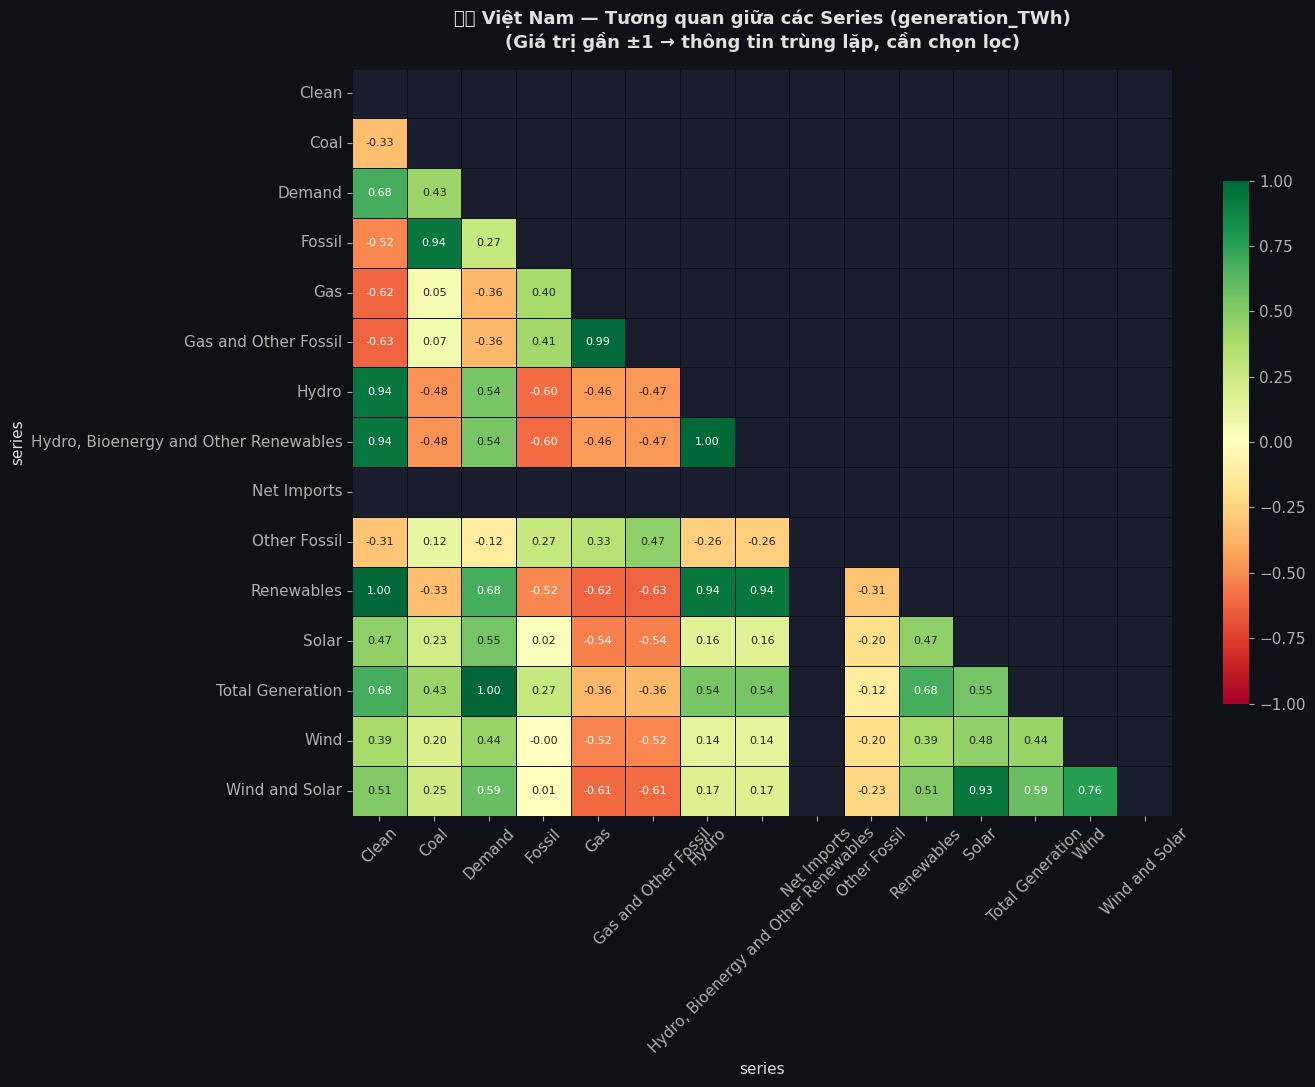


⚠️  Các cặp có tương quan cao (>0.85) — nguy cơ multicollinearity:
   Hydro, Bioenergy and Other Renewables    ↔  Hydro                                     r=1.0
   Renewables                               ↔  Clean                                     r=1.0
   Total Generation                         ↔  Demand                                    r=1.0
   Gas and Other Fossil                     ↔  Gas                                       r=0.989
   Fossil                                   ↔  Coal                                      r=0.937
   Hydro                                    ↔  Clean                                     r=0.936
   Hydro, Bioenergy and Other Renewables    ↔  Clean                                     r=0.936
   Renewables                               ↔  Hydro                                     r=0.936
   Renewables                               ↔  Hydro, Bioenergy and Other Renewables     r=0.936
   Wind and Solar                           ↔  Solar             

In [115]:
# Heatmap tương quan giữa các series cho Việt Nam
vn = df[df['entity'] == 'Viet Nam'].copy()
vn_pivot = vn.pivot_table(index='date', columns='series', values='generation_TWh')

# Drop series with many NaN
vn_pivot = vn_pivot.dropna(thresh=int(len(vn_pivot)*0.5), axis=1)
corr = vn_pivot.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8},
            linewidths=0.5, linecolor='#0f1117',
            cbar_kws={'shrink': 0.7})
ax.set_title('🇻🇳 Việt Nam — Tương quan giữa các Series (generation_TWh)\n'
             '(Giá trị gần ±1 → thông tin trùng lặp, cần chọn lọc)', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# Highlight high correlations
high_corr = []
for i in range(len(corr)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.85:
            high_corr.append((corr.index[i], corr.columns[j], round(val, 3)))
print('\n⚠️  Các cặp có tương quan cao (>0.85) — nguy cơ multicollinearity:')
for a, b, v in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f'   {a:<40} ↔  {b:<40}  r={v}')

---
## 3️⃣  Phân tích xu hướng & mùa vụ

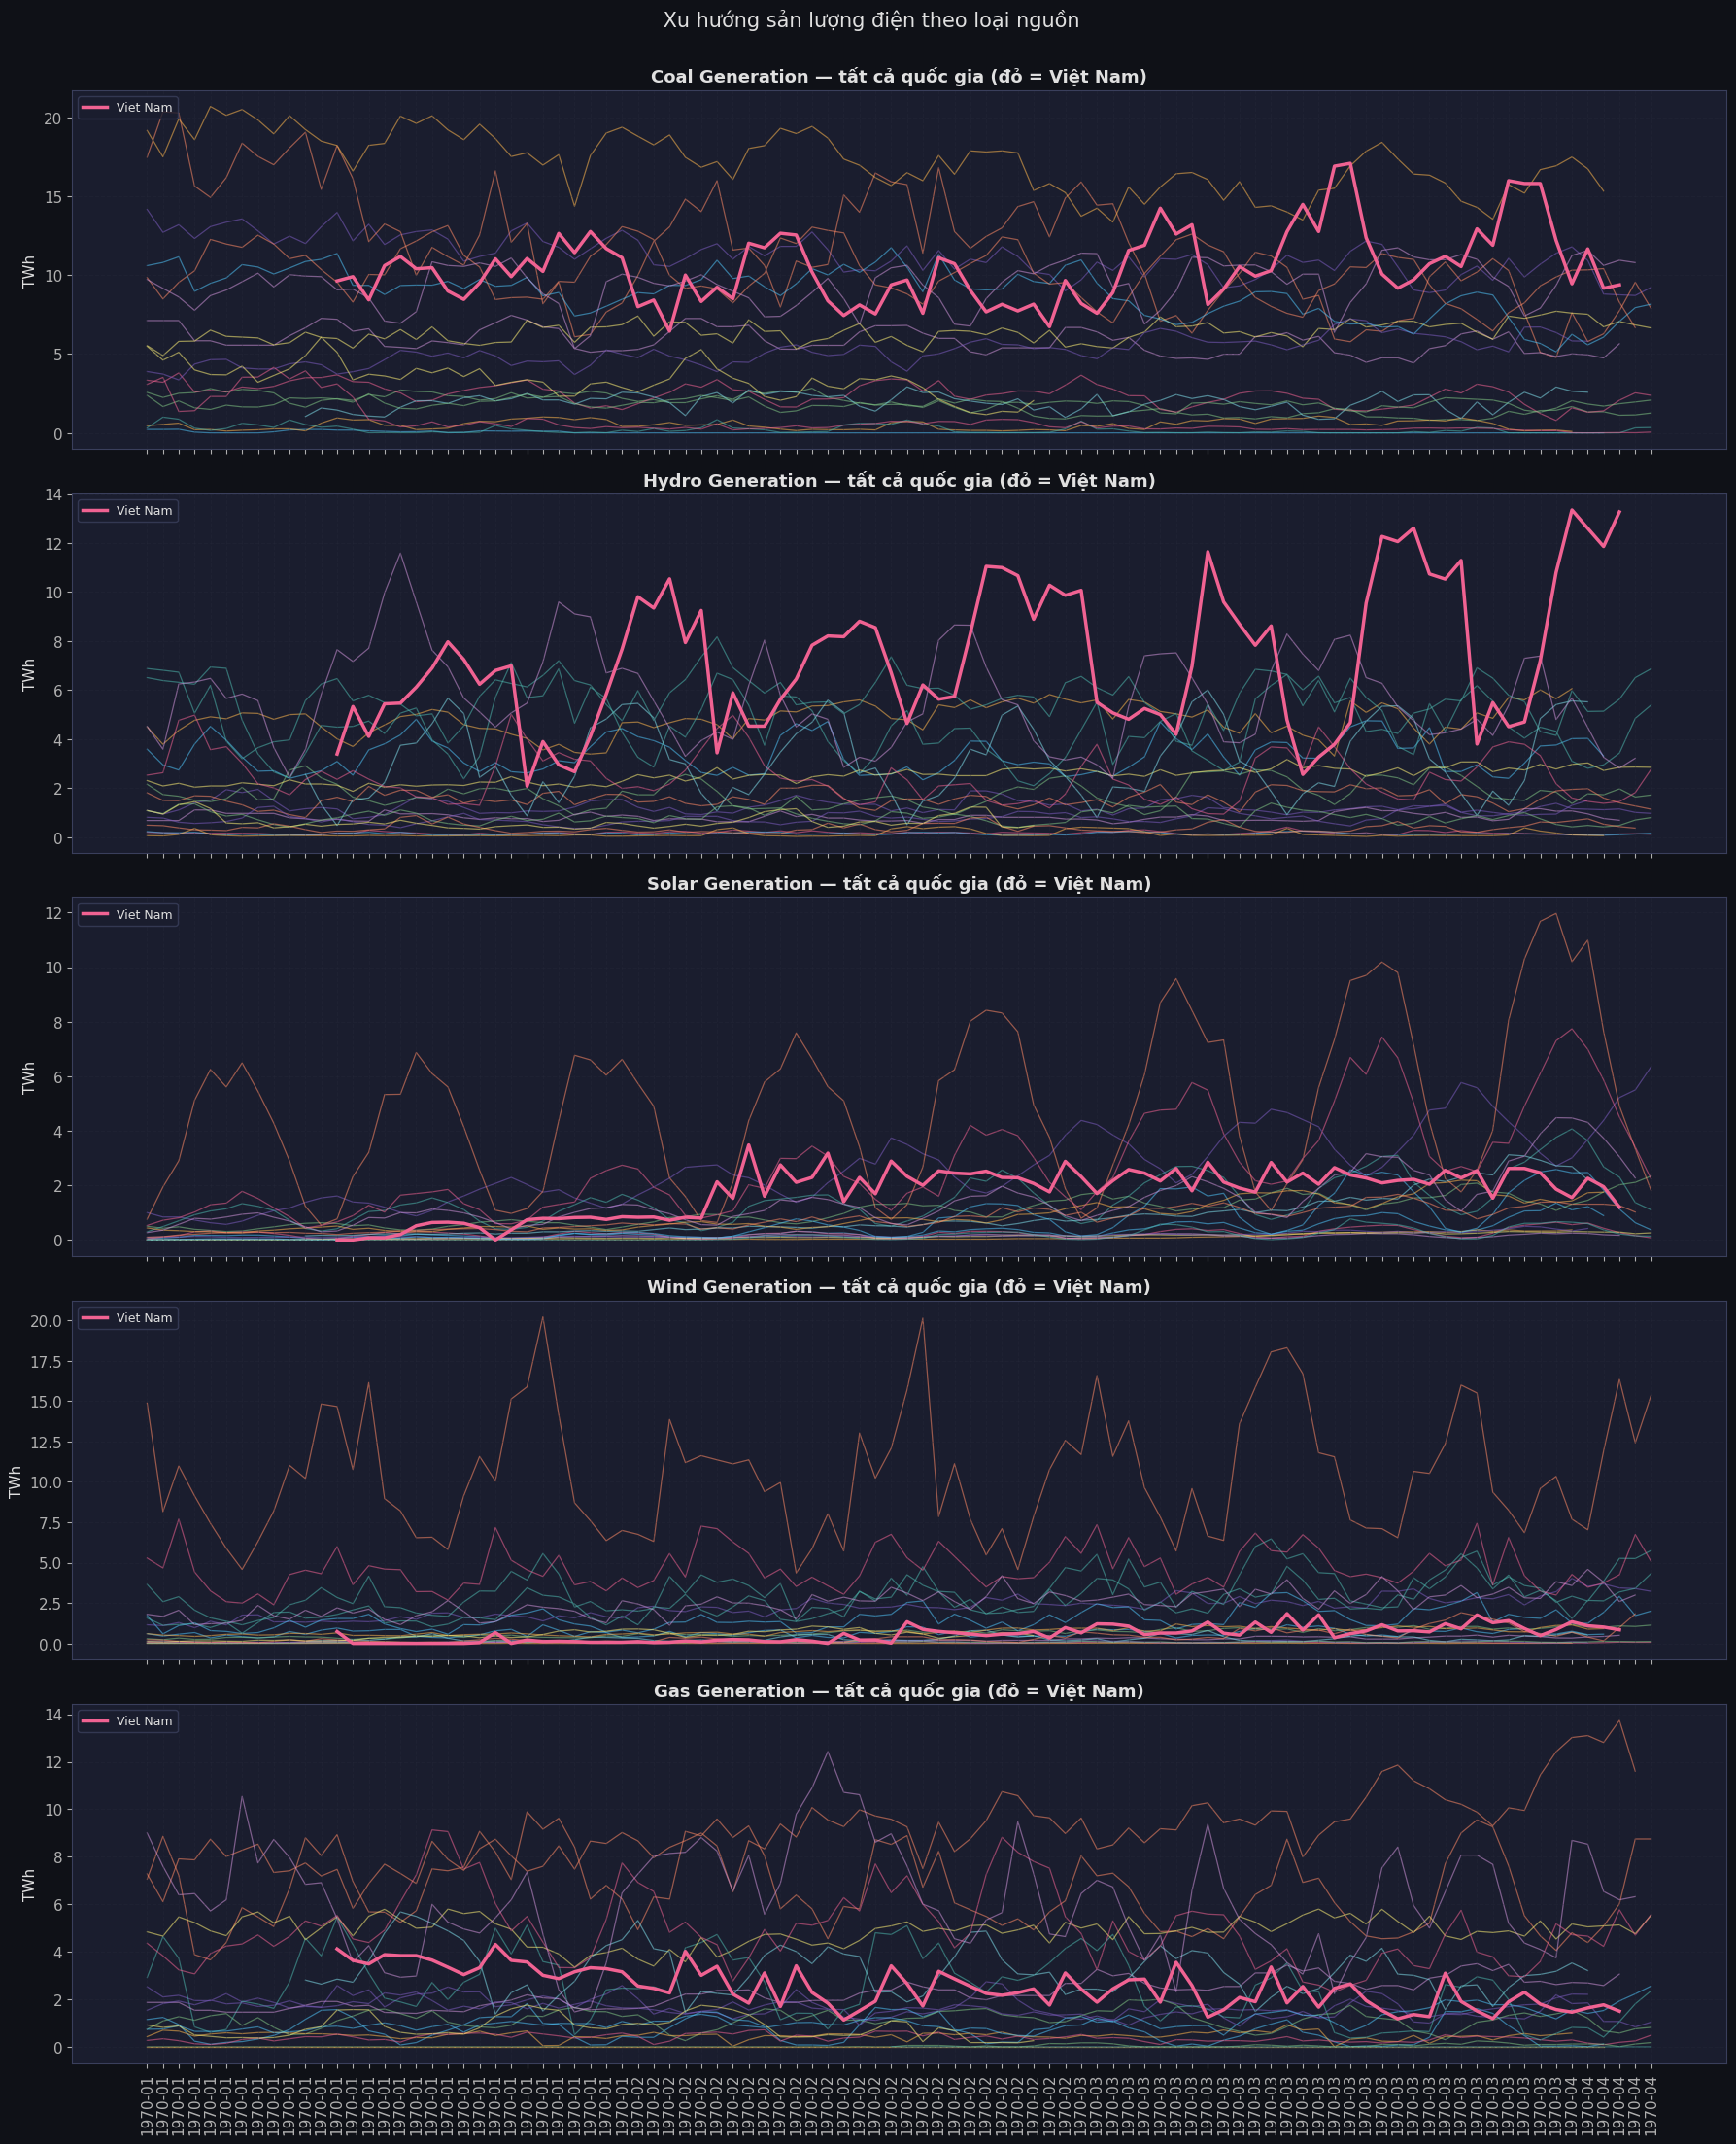

In [116]:
# ── Sản lượng Coal và Hydro theo thời gian cho các quốc gia ────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TARGET_SERIES = ['Coal', 'Hydro', 'Solar', 'Wind', 'Gas']
fig, axes = plt.subplots(len(TARGET_SERIES), 1, figsize=(18, 22), sharex=True)

entities = df['entity'].unique()
color_map = {e: PALETTE[i % len(PALETTE)] for i, e in enumerate(entities)}

for ax, ser in zip(axes, TARGET_SERIES):
    sub = df[df['series'] == ser].sort_values('date')
    for ent, grp in sub.groupby('entity'):
        lw   = 2.5 if ent == 'Viet Nam' else 0.9
        alpha = 1.0 if ent == 'Viet Nam' else 0.55
        zorder = 10 if ent == 'Viet Nam' else 1
        color  = '#f06292' if ent == 'Viet Nam' else color_map[ent]
        ax.plot(grp['date'], grp['generation_TWh'],
                color=color, linewidth=lw, alpha=alpha, zorder=zorder,
                label=ent if ent == 'Viet Nam' else '_')

    ax.set_ylabel('TWh')
    ax.set_title(f'{ser} Generation — tất cả quốc gia (đỏ = Việt Nam)')
    ax.grid(alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

# Cấu hình định dạng ngày tháng và xoay nhãn 90 độ
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Sử dụng tick_params để áp dụng xoay cho trục X của subplot cuối cùng (vì dùng sharex=True)
axes[-1].tick_params(axis='x', rotation=90)

# Hoặc bạn có thể dùng cách này nếu muốn xoay toàn bộ nhãn trên figure:
# plt.xticks(rotation=90)

plt.suptitle(' Xu hướng sản lượng điện theo loại nguồn', fontsize=15, y=1.002)
plt.tight_layout()
plt.show()

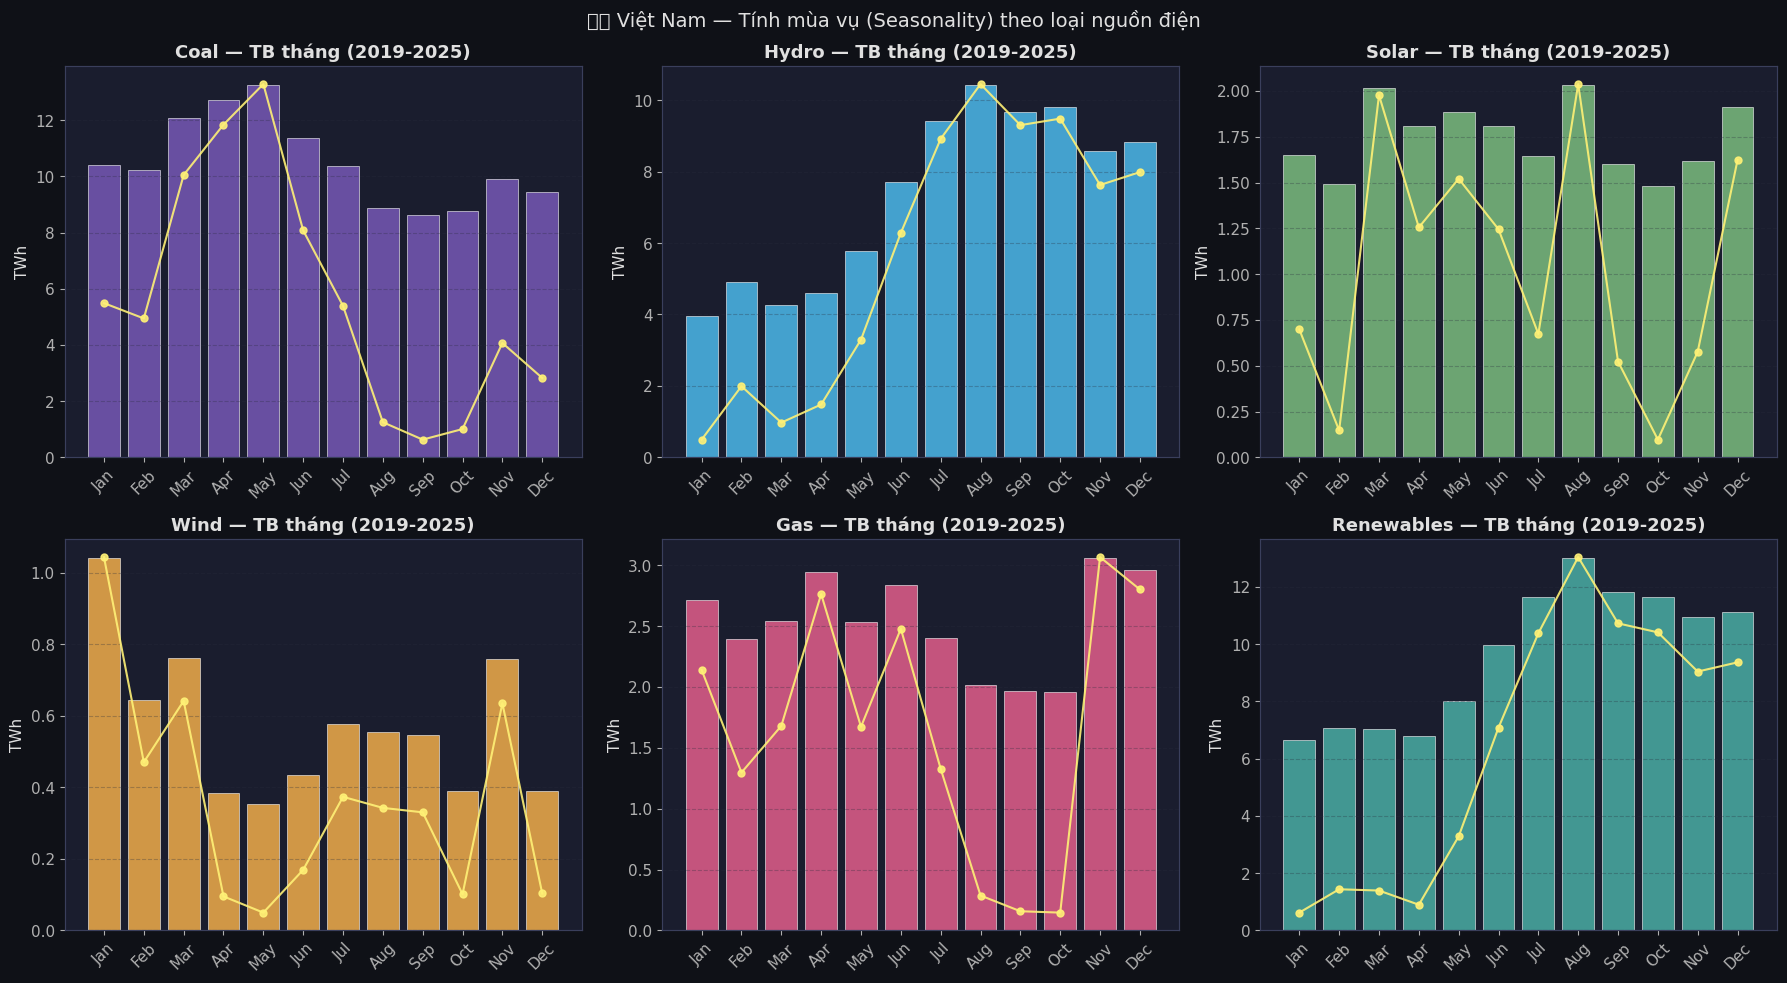


  📌 GHI CHÚ QUAN SÁT:
    • Hydro: cao tháng 6-8 (mùa mưa miền Bắc), giảm mùa khô
    • Coal: tương đối ổn định, nhưng tăng cao mùa khô (Hydro giảm)
    • Solar: cao tháng 3-5 (mùa khô, ít mây miền Nam)
    • Wind: cao tháng 10-1 (gió mùa Đông Bắc)


In [117]:
# ── Phân tích mùa vụ cho Việt Nam ─────────────────────────────────────────────
vn = df[df['entity'] == 'Viet Nam'].copy()
vn['date'] = pd.to_datetime(vn['date'])
vn['month'] = vn['date'].dt.month
vn['year']  = vn['date'].dt.year
vn['month_name'] = vn['date'].dt.strftime('%b')

vn_series_plot = ['Coal', 'Hydro', 'Solar', 'Wind', 'Gas', 'Renewables']
vn_series_plot = [s for s in vn_series_plot if s in vn['series'].unique()]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

months_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, ser in enumerate(vn_series_plot):
    ax = axes[i]
    sub = vn[vn['series'] == ser]
    monthly_avg = sub.groupby('month_name')['generation_TWh'].mean()
    monthly_avg = monthly_avg.reindex([m for m in months_order if m in monthly_avg.index])

    ax.bar(range(len(monthly_avg)), monthly_avg.values,
           color=PALETTE[i], alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(monthly_avg)))
    ax.set_xticklabels(monthly_avg.index, rotation=45)
    ax.set_title(f'{ser} — TB tháng (2019-2025)')
    ax.set_ylabel('TWh')
    ax.grid(axis='y', alpha=0.3)

    # Đường trend
    if len(monthly_avg) > 3:
        ax2 = ax.twinx()
        ax2.plot(range(len(monthly_avg)), monthly_avg.values, 'o-',
                 color='#fff176', linewidth=1.5, markersize=5, alpha=0.9)
        ax2.set_yticks([])

plt.suptitle('🇻🇳 Việt Nam — Tính mùa vụ (Seasonality) theo loại nguồn điện', fontsize=14)
plt.tight_layout()
plt.show()

print('\n  📌 GHI CHÚ QUAN SÁT:')
print('    • Hydro: cao tháng 6-8 (mùa mưa miền Bắc), giảm mùa khô')
print('    • Coal: tương đối ổn định, nhưng tăng cao mùa khô (Hydro giảm)')
print('    • Solar: cao tháng 3-5 (mùa khô, ít mây miền Nam)')
print('    • Wind: cao tháng 10-1 (gió mùa Đông Bắc)')

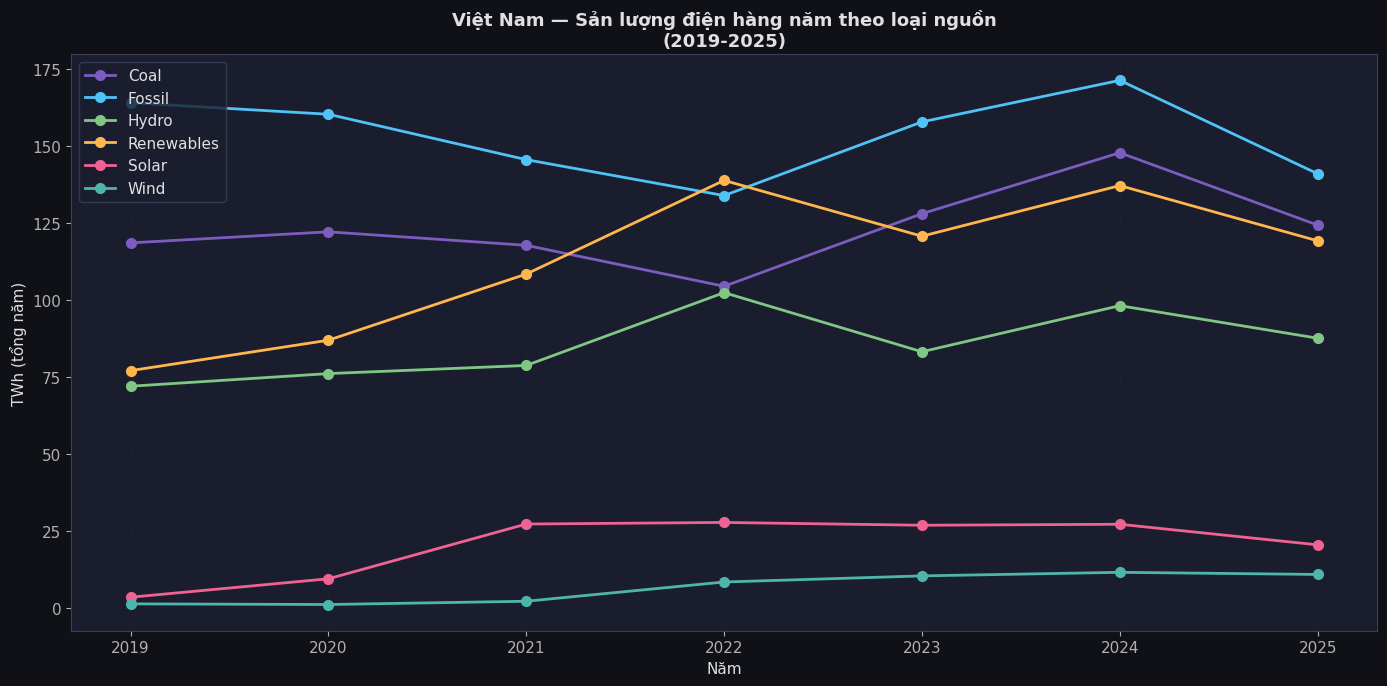

In [118]:
# ── Year-over-Year growth cho Việt Nam ─────────────────────────────────────────
vn_annual = vn.groupby(['year', 'series'])['generation_TWh'].sum().reset_index()
vn_annual = vn_annual[vn_annual['series'].isin(['Coal', 'Hydro', 'Solar', 'Wind', 'Renewables', 'Fossil'])]

fig, ax = plt.subplots(figsize=(14, 7))
for i, ser in enumerate(vn_annual['series'].unique()):
    sub = vn_annual[vn_annual['series'] == ser].sort_values('year')
    ax.plot(sub['year'], sub['generation_TWh'], 'o-',
            color=PALETTE[i], linewidth=2, markersize=7, label=ser)

ax.set_xlabel('Năm')
ax.set_ylabel('TWh (tổng năm)')
ax.set_title('Việt Nam — Sản lượng điện hàng năm theo loại nguồn\n(2019-2025)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

---
## 4️⃣  Phân tích tương quan Thời tiết ↔ Sản lượng điện

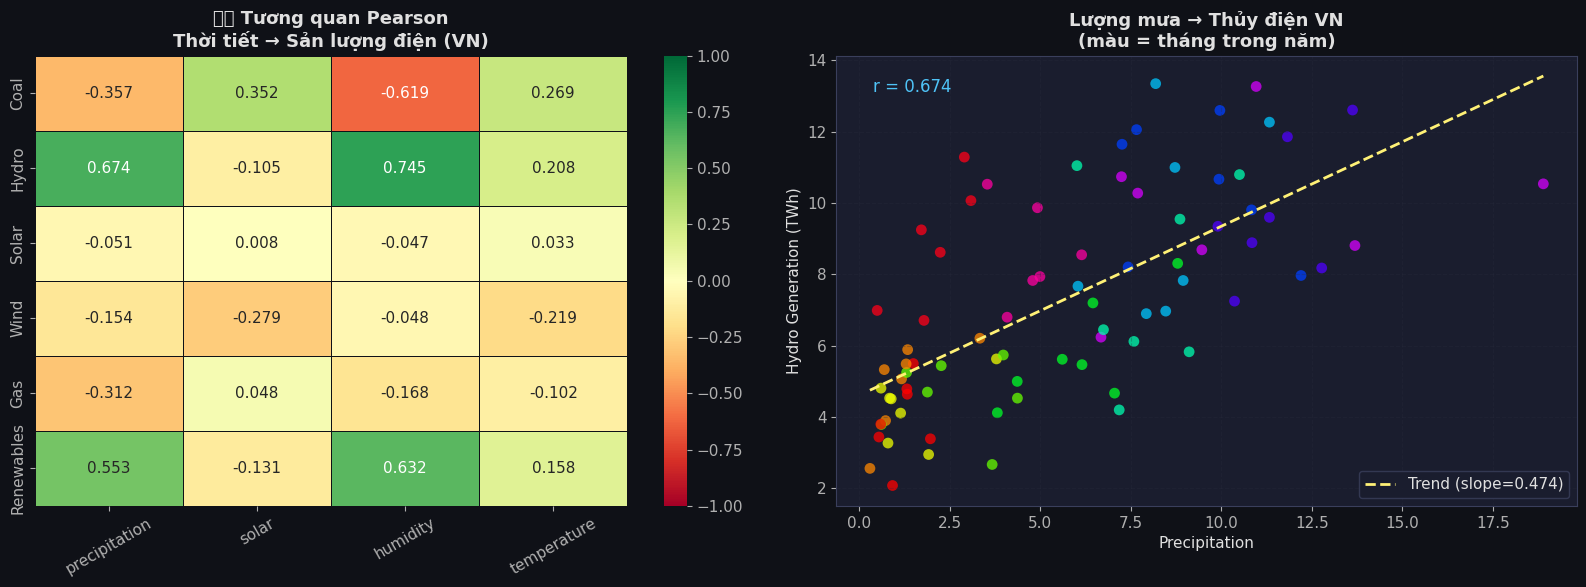

In [119]:
# ── Tương quan thời tiết vs sản lượng — Việt Nam ──────────────────────────────
weather_cols = ['precipitation', 'solar', 'humidity', 'temperature']
target_series_list = ['Coal', 'Hydro', 'Solar', 'Wind', 'Gas', 'Renewables']

corr_matrix = pd.DataFrame(index=target_series_list, columns=weather_cols, dtype=float)

for ser in target_series_list:
    sub = vn[vn['series'] == ser]
    if len(sub) > 10:
        for wc in weather_cols:
            corr_matrix.loc[ser, wc] = sub[wc].corr(sub['generation_TWh'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
ax = axes[0]
corr_vals = corr_matrix.astype(float)
sns.heatmap(corr_vals, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='#0f1117',
            annot_kws={'size': 11})
ax.set_title('🇻🇳 Tương quan Pearson\nThời tiết → Sản lượng điện (VN)')
ax.tick_params(axis='x', rotation=30)

# Scatter — Precipitation vs Hydro
ax = axes[1]
hydro = vn[vn['series'] == 'Hydro'].copy()
hydro['date'] = pd.to_datetime(hydro['date'])
ax.scatter(hydro['precipitation'], hydro['generation_TWh'],
           c=hydro['date'].dt.month, cmap='hsv', alpha=0.75, s=60, edgecolors='none')
m, b = np.polyfit(hydro['precipitation'].fillna(0), hydro['generation_TWh'].fillna(0), 1)
x_line = np.linspace(hydro['precipitation'].min(), hydro['precipitation'].max(), 100)
ax.plot(x_line, m*x_line + b, '--', color='#fff176', linewidth=2, label=f'Trend (slope={m:.3f})')
ax.set_xlabel('Precipitation')
ax.set_ylabel('Hydro Generation (TWh)')
ax.set_title('Lượng mưa → Thủy điện VN\n(màu = tháng trong năm)')
ax.legend()
r = hydro['precipitation'].corr(hydro['generation_TWh'])
ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
        fontsize=12, color='#4fc3f7')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

📌 LAG CORRELATION — Precipitation → Hydro Generation (Việt Nam)
  Lag -3 tháng : r = 0.2853
  Lag -2 tháng : r = 0.6274
  Lag -1 tháng : r = 0.7156
  Lag +0 tháng : r = 0.6740
  Lag +1 tháng : r = 0.4466
  Lag +2 tháng : r = 0.1718
  Lag +3 tháng : r = -0.2104
  Lag +4 tháng : r = -0.5690
  Lag +5 tháng : r = -0.7116
  Lag +6 tháng : r = -0.6048


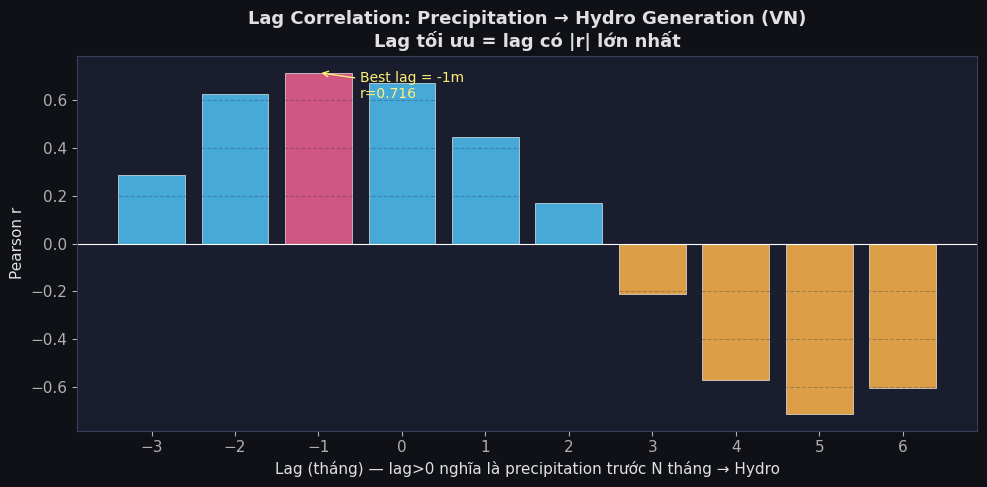


  ➤ Best lag = -1 tháng (r=0.7156)
  ➤ Gợi ý: Tạo feature "precipitation_lag-1" làm known covariate!


In [120]:
# ── Lag correlation analysis ───────────────────────────────────────────────────
# Hydro production thường có lag so với lượng mưa (nước tích hồ)
print('📌 LAG CORRELATION — Precipitation → Hydro Generation (Việt Nam)')
print('='*60)

hydro = vn[vn['series'] == 'Hydro'].sort_values('date').copy()
lags = range(-3, 7)  # -3 đến +6 tháng
lag_corrs = {}
for lag in lags:
    shifted_prec = hydro['precipitation'].shift(-lag)  # lag > 0: prec trước hydro
    c = shifted_prec.corr(hydro['generation_TWh'])
    lag_corrs[lag] = c
    print(f'  Lag {lag:+d} tháng : r = {c:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
lags_list = list(lag_corrs.keys())
corrs_list = list(lag_corrs.values())
colors_lag = ['#f06292' if abs(v) == max([abs(c) for c in corrs_list]) else
              ('#4fc3f7' if v > 0 else '#ffb74d') for v in corrs_list]
ax.bar(lags_list, corrs_list, color=colors_lag, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_xlabel('Lag (tháng) — lag>0 nghĩa là precipitation trước N tháng → Hydro')
ax.set_ylabel('Pearson r')
ax.set_title('Lag Correlation: Precipitation → Hydro Generation (VN)\n'
             'Lag tối ưu = lag có |r| lớn nhất')
ax.set_xticks(lags_list)
ax.grid(axis='y', alpha=0.3)
best_lag = max(lag_corrs, key=lambda k: abs(lag_corrs[k]))
ax.annotate(f'Best lag = {best_lag}m\nr={lag_corrs[best_lag]:.3f}',
            xy=(best_lag, lag_corrs[best_lag]),
            xytext=(best_lag+0.5, lag_corrs[best_lag]*0.85),
            fontsize=10, color='#fff176',
            arrowprops={'arrowstyle': '->', 'color': '#fff176'})
plt.tight_layout()
plt.show()

print(f'\n  ➤ Best lag = {best_lag} tháng (r={lag_corrs[best_lag]:.4f})')
print(f'  ➤ Gợi ý: Tạo feature "precipitation_lag{best_lag}" làm known covariate!')

---
## 5️⃣  Tóm tắt vấn đề & Đề xuất Feature Engineering cho TFT

In [121]:
summary = """
╔══════════════════════════════════════════════════════════════════════════════════════╗
║         TÓM TẮT VẤN ĐỀ & GIẢI PHÁP — Chuẩn bị dữ liệu cho TFT                    ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ VĐ 1 — DUPLICATES (~29% rows bị nhân đôi do merge nhiều vùng thời tiết)            ║
║   FIX: groupby(['entity','series','date']).agg('mean') → dedup                     ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ VĐ 2 — ZEROS & NEGATIVES                                                           ║
║   FIX: Giữ nguyên zeros (nghĩa vật lý); clip negative nếu loại bỏ Net Imports      ║
║        Dùng log1p transform cho target: log(1 + generation_TWh)                    ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ VĐ 3 — PRECIPITATION SCALE INCONSISTENCY (Colombia ~8000 vs Germany ~62)           ║
║   FIX: Normalize per-entity (StandardScaler/MinMaxScaler per group)                ║
║        HOẶC: log1p(precipitation) → giảm ảnh hưởng extreme values                 ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ VĐ 4 — TIME GAP (Colombia/Wind ~6 tháng; Ukraine chỉ đến 2022-09)                 ║
║   FIX: Linear interpolation cho gap ≤ 3 tháng                                     ║
║        Loại Ukraine nếu cần chuỗi đủ dài (min_encoder_length requirement)          ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ VĐ 5 — OUTLIERS trong generation_TWh (12.55%)                                     ║
║   FIX: Không clip — dùng normalization theo group (entity+series)                  ║
║        TFT xử lý được outliers khi normalize đúng                                  ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ VĐ 6 — SERIES REDUNDANCY (Fossil=Coal+Gas+Other, Total≈Demand, v.v.)              ║
║   FIX: Chọn 1 target series; dùng các series khác làm known_reals/observed        ║
║        Loại bỏ: CO2 intensity, Day-ahead price (khác đơn vị)                      ║
╚══════════════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════════════════════╗
║         TÓM TẮT VẤN ĐỀ & GIẢI PHÁP — Chuẩn bị dữ liệu cho TFT                    ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ VĐ 1 — DUPLICATES (~29% rows bị nhân đôi do merge nhiều vùng thời tiết)            ║
║   FIX: groupby(['entity','series','date']).agg('mean') → dedup                     ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ VĐ 2 — ZEROS & NEGATIVES                                                           ║
║   FIX: Giữ nguyên zeros (nghĩa vật lý); clip negative nếu loại bỏ Net Imports      ║
║        Dùng log1p transform cho target: log(1 + generation_TWh)                    ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ VĐ 3 — PRECIPITATION SCALE INCONSISTENCY (Colombia ~8000 vs Germany ~62)           ║
║   FIX: Normalize per-entity (Stand

In [122]:
fe_plan = """
╔══════════════════════════════════════════════════════════════════════════════════════╗
║               KẾ HOẠCH FEATURE ENGINEERING cho TFT                                 ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  A. TEMPORAL FEATURES (time_varying_known_reals)                                   ║
║    ├─ month          : tháng trong năm (1-12) → seasonality                        ║
║    ├─ month_sin/cos  : sin/cos encoding tránh discontinuity tháng 12→1             ║
║    ├─ quarter        : quý (1-4)                                                   ║
║    ├─ year           : năm (trend dài hạn)                                         ║
║    ├─ time_idx       : integer index (required by TFT)                             ║
║    └─ is_dry_season  : binary 0/1 (tháng khô/mưa theo quốc gia)                  ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  B. LAG FEATURES (time_varying_known_reals — nếu future known)                     ║
║    ├─ generation_lag_1    : t-1 (giá trị tháng trước)                             ║
║    ├─ generation_lag_3    : t-3 (giá trị 3 tháng trước)                           ║
║    ├─ generation_lag_12   : t-12 (cùng tháng năm ngoái — rất quan trọng!)         ║
║    ├─ precipitation_lag_1 : lượng mưa tháng trước → Hydro                         ║
║    └─ precipitation_lag_2 : lượng mưa 2 tháng trước → Hydro                      ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  C. ROLLING STATISTICS (time_varying_unknown_reals — observe từ lịch sử)           ║
║    ├─ roll_mean_3   : rolling mean 3 tháng → short-term trend                     ║
║    ├─ roll_mean_6   : rolling mean 6 tháng → medium-term trend                    ║
║    ├─ roll_std_3    : rolling std 3 tháng → variability                           ║
║    ├─ roll_max_6    : rolling max 6 tháng → peak capacity                         ║
║    └─ yoy_change    : (t - t_12) / t_12 → year-over-year growth rate              ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  D. CROSS-SERIES FEATURES (correlation with Hydro/Solar/Wind)                      ║
║    ├─ hydro_ratio   : Hydro / Total_Generation → share của thủy điện              ║
║    ├─ renewable_ratio: Renewables / Total_Generation                               ║
║    └─ coal_hydro_ratio: Coal / Hydro → thay thế chéo (negative corr)              ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  E. WEATHER TRANSFORMATIONS                                                        ║
║    ├─ log_precipitation : log1p(precipitation) → giảm skewness                   ║
║    ├─ prec_zscore_entity: precipitation chuẩn hóa theo từng quốc gia             ║
║    ├─ solar_norm        : solar / max_solar_entity → 0-1 per entity              ║
║    └─ temp_anomaly      : temperature - monthly_mean_temp → deviation             ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  F. STATIC CATEGORICAL FEATURES (static_categoricals)                              ║
║    ├─ entity            : quốc gia (group_id của TFT)                             ║
║    └─ climate_zone      : tropical/temperate/arid (nhóm khí hậu)                 ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  G. TARGET TRANSFORMATION                                                          ║
║    ├─ TFT target: generation_TWh (raw, dùng GroupNormalizer trong TFT)            ║
║    ├─ HOẶC: log1p(generation_TWh) nếu distribution lệch nhiều                    ║
║    └─ Dùng TimeSeriesDataSet(target_normalizer=GroupNormalizer()) → per-entity    ║
╚══════════════════════════════════════════════════════════════════════════════════════╝
"""
print(fe_plan)


╔══════════════════════════════════════════════════════════════════════════════════════╗
║               KẾ HOẠCH FEATURE ENGINEERING cho TFT                                 ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  A. TEMPORAL FEATURES (time_varying_known_reals)                                   ║
║    ├─ month          : tháng trong năm (1-12) → seasonality                        ║
║    ├─ month_sin/cos  : sin/cos encoding tránh discontinuity tháng 12→1             ║
║    ├─ quarter        : quý (1-4)                                                   ║
║    ├─ year           : năm (trend dài hạn)                                         ║
║    ├─ time_idx       : integer index (required by TFT)                             ║
║    └─ is_dry_season  : binary 0/1 (tháng khô/mưa theo quốc gia)                  ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║  B. LAG FEATURES (time_varying_known

In [123]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DEMO FEATURE ENGINEERING — áp dụng thực tế trên dataset
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Step 0: Dedup
df_fe = df_raw.copy()
df_fe['date'] = pd.to_datetime(df_fe['date'])
df_fe = df_fe.groupby(['entity', 'entity code', 'date', 'series'], as_index=False).agg({
    'generation_TWh': 'mean',
    'precipitation':  'mean',
    'solar':          'mean',
    'humidity':       'mean',
    'temperature':    'mean',
})
df_fe = df_fe.sort_values(['entity', 'series', 'date']).reset_index(drop=True)

# Step 1: Temporal features
df_fe['month']      = df_fe['date'].dt.month
df_fe['quarter']    = df_fe['date'].dt.quarter
df_fe['year']       = df_fe['date'].dt.year
df_fe['month_sin']  = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos']  = np.cos(2 * np.pi * df_fe['month'] / 12)

# time_idx per entity-series group
df_fe['time_idx'] = df_fe.groupby(['entity', 'series'])['date'].rank(method='dense').astype(int) - 1

# Step 2: Lag & rolling features (per entity-series)
def add_lags_rolling(group):
    group = group.sort_values('date').copy()
    g = group['generation_TWh']
    group['gen_lag_1']   = g.shift(1)
    group['gen_lag_3']   = g.shift(3)
    group['gen_lag_12']  = g.shift(12)
    group['roll_mean_3'] = g.shift(1).rolling(3, min_periods=2).mean()
    group['roll_mean_6'] = g.shift(1).rolling(6, min_periods=3).mean()
    group['roll_std_3']  = g.shift(1).rolling(3, min_periods=2).std()
    group['roll_max_6']  = g.shift(1).rolling(6, min_periods=3).max()
    # YoY change rate
    group['yoy_change']  = (g - g.shift(12)) / (g.shift(12).abs() + 1e-6)
    # Precipitation lags
    group['prec_lag_1']  = group['precipitation'].shift(1)
    group['prec_lag_2']  = group['precipitation'].shift(2)
    return group

print('⏳ Đang tạo lag & rolling features...')
df_fe = df_fe.groupby(['entity', 'series'], group_keys=False).apply(add_lags_rolling)

# Step 3: Weather transformations
df_fe['log_precipitation'] = np.log1p(df_fe['precipitation'])

# Z-score precipitation per entity
def zscore_entity(group):
    mu  = group['precipitation'].mean()
    std = group['precipitation'].std() + 1e-6
    group['prec_zscore'] = (group['precipitation'] - mu) / std
    return group

df_fe = df_fe.groupby('entity', group_keys=False).apply(zscore_entity)

# Solar normalized per entity (0-1)
df_fe['solar_norm'] = df_fe.groupby('entity')['solar'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6))

# Temperature anomaly (vs monthly mean per entity)
temp_monthly_mean = df_fe.groupby(['entity', 'month'])['temperature'].transform('mean')
df_fe['temp_anomaly'] = df_fe['temperature'] - temp_monthly_mean

# Step 4: Target log transform
df_fe['log_generation'] = np.log1p(df_fe['generation_TWh'])

print(f'✅ Feature engineering hoàn tất!')
print(f'   Từ {9} columns → {df_fe.shape[1]} columns')
print(f'   Rows: {len(df_fe):,}')
print()
new_cols = [c for c in df_fe.columns if c not in ['entity','entity code','date','series',
             'generation_TWh','precipitation','solar','humidity','temperature']]
print('  Các feature mới được tạo:')
for c in new_cols:
    print(f'    ✦ {c}')

⏳ Đang tạo lag & rolling features...
✅ Feature engineering hoàn tất!
   Từ 9 columns → 30 columns
   Rows: 30,290

  Các feature mới được tạo:
    ✦ month
    ✦ quarter
    ✦ year
    ✦ month_sin
    ✦ month_cos
    ✦ time_idx
    ✦ gen_lag_1
    ✦ gen_lag_3
    ✦ gen_lag_12
    ✦ roll_mean_3
    ✦ roll_mean_6
    ✦ roll_std_3
    ✦ roll_max_6
    ✦ yoy_change
    ✦ prec_lag_1
    ✦ prec_lag_2
    ✦ log_precipitation
    ✦ prec_zscore
    ✦ solar_norm
    ✦ temp_anomaly
    ✦ log_generation


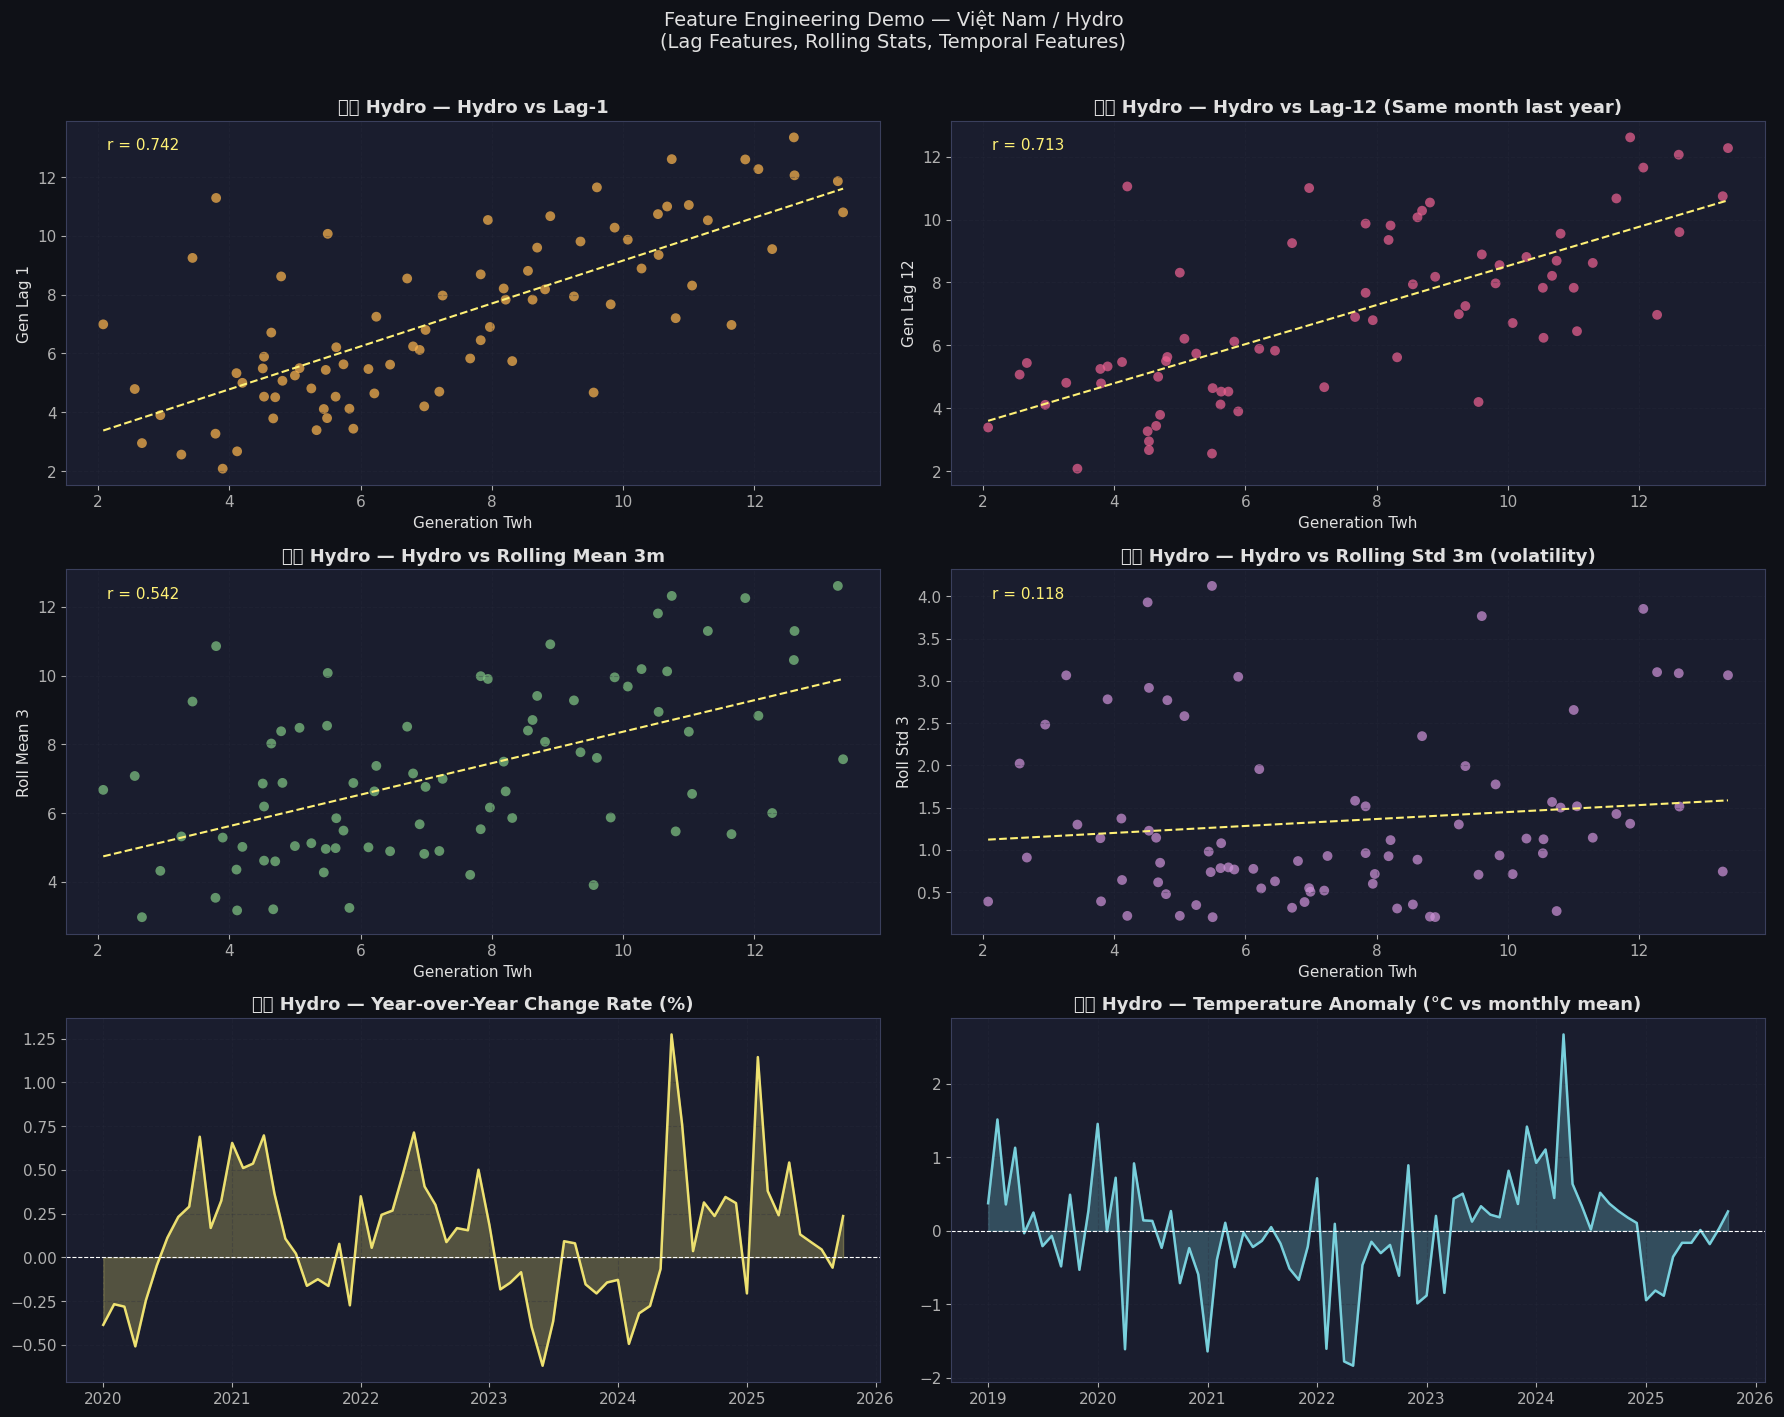

In [124]:
# ── Visualize lag features cho Việt Nam / Hydro ────────────────────────────────
vn_hydro_fe = df_fe[(df_fe['entity'] == 'Viet Nam') & (df_fe['series'] == 'Hydro')].sort_values('date')

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

plots = [
    ('generation_TWh', 'gen_lag_1',  'Hydro vs Lag-1', '#4fc3f7', '#ffb74d'),
    ('generation_TWh', 'gen_lag_12', 'Hydro vs Lag-12 (Same month last year)', '#4fc3f7', '#f06292'),
    ('generation_TWh', 'roll_mean_3','Hydro vs Rolling Mean 3m', '#4fc3f7', '#81c784'),
    ('generation_TWh', 'roll_std_3', 'Hydro vs Rolling Std 3m (volatility)', '#4fc3f7', '#ce93d8'),
    ('date',           'yoy_change', 'Year-over-Year Change Rate (%)', None, '#fff176'),
    ('date',           'temp_anomaly','Temperature Anomaly (°C vs monthly mean)', None, '#80deea'),
]

for i, (x_col, y_col, title, color1, color2) in enumerate(plots):
    ax = axes[i]
    sub = vn_hydro_fe.dropna(subset=[y_col])
    if x_col == 'date':
        ax.plot(sub[x_col], sub[y_col], color=color2, linewidth=1.8, alpha=0.9)
        ax.fill_between(sub[x_col], sub[y_col], 0, alpha=0.25, color=color2)
        ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
    else:
        ax.scatter(sub[x_col], sub[y_col], c=color2, alpha=0.7, s=50, edgecolors='none')
        r = sub[x_col].corr(sub[y_col])
        ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
                fontsize=11, color='#fff176')
        if not sub.empty:
            m, b = np.polyfit(sub[x_col].fillna(0), sub[y_col].fillna(0), 1)
            xl = np.linspace(sub[x_col].min(), sub[x_col].max(), 50)
            ax.plot(xl, m*xl + b, '--', color='#fff176', linewidth=1.5)
        ax.set_xlabel(x_col.replace('_', ' ').title())
        ax.set_ylabel(y_col.replace('_', ' ').title())
    ax.set_title(f'🇻🇳 Hydro — {title}')
    ax.grid(alpha=0.3)

plt.suptitle('Feature Engineering Demo — Việt Nam / Hydro\n'
             '(Lag Features, Rolling Stats, Temporal Features)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [125]:
# ── Hướng dẫn cấu hình TFT TimeSeriesDataSet ──────────────────────────────────
tft_guide = """
╔══════════════════════════════════════════════════════════════════════════════╗
║       HƯỚNG DẪN CẤU HÌNH TimeSeriesDataSet cho TFT                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer         ║
║                                                                              ║
║  dataset = TimeSeriesDataSet(                                               ║
║    df_fe,                                                                    ║
║    time_idx       = 'time_idx',                                              ║
║    target         = 'generation_TWh',      # hoặc 'log_generation'          ║
║    group_ids      = ['entity', 'series'],  # mỗi (country, energy_type)     ║
║    max_encoder_length = 24,               # 24 tháng lịch sử               ║
║    max_prediction_length = 6,             # dự báo 6 tháng tới             ║
║                                                                              ║
║    # Đặc trưng tĩnh (không thay đổi theo thời gian)                        ║
║    static_categoricals  = ['entity'],                                       ║
║    static_reals         = [],                                                ║
║                                                                              ║
║    # Known covariates (biết trước cả tương lai)                             ║
║    time_varying_known_categoricals = [],                                     ║
║    time_varying_known_reals = [                                              ║
║        'time_idx', 'month', 'month_sin', 'month_cos', 'quarter', 'year',   ║
║        'solar',           # bức xạ mặt trời (có thể dự báo tương lai)     ║
║        'temperature',     # nhiệt độ (có thể dự báo từ weather forecast)   ║
║        'humidity',        # độ ẩm                                           ║
║    ],                                                                        ║
║                                                                              ║
║    # Unknown covariates (chỉ biết từ lịch sử)                              ║
║    time_varying_unknown_reals = [                                            ║
║        'generation_TWh',  # target (autoregressive)                         ║
║        'precipitation', 'log_precipitation', 'prec_zscore',                 ║
║        'gen_lag_1', 'gen_lag_3', 'gen_lag_12',                             ║
║        'roll_mean_3', 'roll_mean_6', 'roll_std_3', 'roll_max_6',           ║
║        'yoy_change', 'temp_anomaly', 'solar_norm',                          ║
║        'prec_lag_1', 'prec_lag_2',                                          ║
║    ],                                                                        ║
║                                                                              ║
║    target_normalizer = GroupNormalizer(                                      ║
║        groups=['entity', 'series'],        # normalize per country+type     ║
║        transformation='softplus',          # handles near-zero values       ║
║    ),                                                                        ║
║    add_relative_time_idx  = True,                                            ║
║    add_target_scales      = True,                                            ║
║    add_encoder_length     = True,                                            ║
║    allow_missing_timesteps = True,         # xử lý gap trong chuỗi         ║
║  )                                                                           ║
║                                                                              ║
║  LƯU Ý:                                                                     ║
║  • min_series_length = max_encoder_length + max_prediction_length = 30m    ║
║  • Ukraine (~57m) đủ; cần lọc bỏ series có len < 30                       ║
║  • GroupNormalizer giải quyết cả VĐ 3 (precipitation scale) và VĐ 5       ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(tft_guide)


╔══════════════════════════════════════════════════════════════════════════════╗
║       HƯỚNG DẪN CẤU HÌNH TimeSeriesDataSet cho TFT                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer         ║
║                                                                              ║
║  dataset = TimeSeriesDataSet(                                               ║
║    df_fe,                                                                    ║
║    time_idx       = 'time_idx',                                              ║
║    target         = 'generation_TWh',      # hoặc 'log_generation'          ║
║    group_ids      = ['entity', 'series'],  # mỗi (country, energy_type)     ║
║    max_encoder_length = 24,               # 24 tháng lịch sử               ║
║    max_prediction_length = 6,    

In [126]:
# ── Save processed dataset ─────────────────────────────────────────────────────
out_path = r'C:\Users\ADMIN\Downloads\MODEL_TFT\data\processed\tft_premodel_dataset_EDA.csv'
df_fe.to_csv(out_path, index=False)

print(f'✅ Dataset đã lưu tại: {out_path}')
print(f'   Shape: {df_fe.shape}')
print(f'   Tổng NaN sau FE (do lag đầu chuỗi — bình thường):')
nan_cols = df_fe.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
print(nan_cols.to_string())
print()
print('📌 Các bước TIẾP THEO:')
print('  1. Lọc entity-series có đủ độ dài (min 30+ tháng)')
print('  2. Xử lý NaN từ lag features bằng dropna hoặc fill_value=0')
print('  3. Chuẩn bị TimeSeriesDataSet với config ở cell trên')
print('  4. Train TFT với GroupNormalizer để xử lý scale khác nhau')

✅ Dataset đã lưu tại: C:\Users\ADMIN\Downloads\MODEL_TFT\data\processed\tft_premodel_dataset_EDA.csv
   Shape: (30290, 30)
   Tổng NaN sau FE (do lag đầu chuỗi — bình thường):
gen_lag_1          332
gen_lag_3          996
gen_lag_12        3984
roll_mean_3        664
roll_mean_6        996
roll_std_3         664
roll_max_6         996
yoy_change        3984
prec_lag_1         332
prec_lag_2         664
log_generation     291

📌 Các bước TIẾP THEO:
  1. Lọc entity-series có đủ độ dài (min 30+ tháng)
  2. Xử lý NaN từ lag features bằng dropna hoặc fill_value=0
  3. Chuẩn bị TimeSeriesDataSet với config ở cell trên
  4. Train TFT với GroupNormalizer để xử lý scale khác nhau
